# The Value of Rainfall Forecasts for PPO-Based Irrigation Timing and Field Prioritization
## Project Overview

This project investigates whether short-term rainfall forecasts improve irrigation decisions learned by Proximal Policy Optimization (PPO), and whether the value of forecast information changes under different seasonal water constraints.

The irrigation problem contains three heterogeneous fields sharing one seasonal water budget. Each day, the PPO agent decides whether to irrigate and which field or field combination should receive water. The fields differ in moisture targets, irrigation thresholds, irrigation efficiency, and daily water loss, creating a joint irrigation-timing and field-prioritization problem.

The PPO workflow and weather-data preparation were adapted from the AquaCrop-Gym framework. The environment was redesigned for this project as a lightweight soil-water control model with three fields, a shared seasonal budget, discrete irrigation actions, and budget-based action masking.

Three forecast treatments are compared:

1. **No Forecast** — no future rainfall information;
2. **Perfect Forecast** — true rainfall from day \(t\) to day \(t+2\);
3. **Noisy Forecast** — the same three-day rainfall forecast with added noise.

All treatments use the same realized rainfall, PPO architecture, and final holdout weather years. Therefore, differences in performance can be attributed to the rainfall information available to the agent.

The treatments are evaluated under two seasonal water budgets:

- **Moderate:** 1,800 mm;
- **Abundant:** 2,400 mm.

The main evaluation focuses on cumulative reward, weather-year variability, field-level irrigation allocation, drought stress, water use, benchmark performance, forecast-input ablation, and training-seed sensitivity.

# 1. Setup and Imports

This section imports the libraries used for weather-data preparation, environment configuration, baseline optimization, PPO training, evaluation, and visualization.


In [8]:
from __future__ import annotations

import copy
import csv
import gc
import hashlib
import json
import logging
import pickle
import random
import shutil
import importlib
import sys

# Allow Python to import local project modules
project_root_text = str(PROJECT_ROOT)

if project_root_text not in sys.path:
    sys.path.insert(0, project_root_text)

importlib.invalidate_caches()

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Mapping, Optional, Sequence

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ray
import torch
from IPython.display import display
from scipy.optimize import differential_evolution

logging.getLogger("ray._common.deprecation").setLevel(logging.ERROR)

from ray.rllib.algorithms.algorithm import Algorithm
from ray.rllib.algorithms.ppo import PPOConfig
from ray.rllib.core.columns import Columns
from ray.rllib.core.rl_module.default_model_config import DefaultModelConfig
from ray.rllib.core.rl_module.rl_module import RLModule, RLModuleSpec
from ray.rllib.examples.rl_modules.classes.action_masking_rlm import (
    ActionMaskingTorchRLModule,
)


# 2. Project Paths

Define the input and output paths used in the experiments.



In [9]:
from pathlib import Path


def find_project_root() -> Path:
    """Locate the project folder from the current directory or its parents."""

    current_dir = Path.cwd().resolve()

    for candidate in [current_dir, *current_dir.parents]:
        if (
            (candidate / "irrigation_env.py").is_file()
            and (candidate / "experiment_protocol.py").is_file()
            and (candidate / "data").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project folder.\n"
        "Expected a folder containing:\n"
        "- irrigation_env.py\n"
        "- experiment_protocol.py\n"
        "- data/"
    )


PROJECT_ROOT = find_project_root()

DATA_ROOT = PROJECT_ROOT / "data"
OUTPUTS_ROOT = PROJECT_ROOT / "outputs"

WEATHER_DATA_PATH = DATA_ROOT / "CPWG_processed.csv"

BASELINE_OUTPUT_ROOT = OUTPUTS_ROOT / "baselines_final_v1"
PPO_OUTPUT_ROOT = OUTPUTS_ROOT / "formal_ppo_final_v1"
PPO_INITIAL_STATE_ROOT = PPO_OUTPUT_ROOT / "initial_states"
HOLDOUT_OUTPUT_ROOT = OUTPUTS_ROOT / "final_holdout_31_40_v1"
ANALYSIS_OUTPUT_ROOT = OUTPUTS_ROOT / "final_analysis_v1"
ANALYSIS_PRESENTATION_ROOT = (
    ANALYSIS_OUTPUT_ROOT / "presentation_figures"
)

HOLDOUT_MAIN_EPISODE_PATH = (
    HOLDOUT_OUTPUT_ROOT / "main_episode_metrics.csv"
)
HOLDOUT_MAIN_DAILY_PATH = (
    HOLDOUT_OUTPUT_ROOT / "main_daily_trajectories.csv"
)
HOLDOUT_ABLATION_EPISODE_PATH = (
    HOLDOUT_OUTPUT_ROOT
    / "perfect_forecast_ablation_episode_metrics.csv"
)
HOLDOUT_ABLATION_DAILY_PATH = (
    HOLDOUT_OUTPUT_ROOT
    / "perfect_forecast_ablation_daily.csv"
)

RECOMPUTE_EXPERIMENTS = False

def read_json(path: Path) -> dict[str, Any]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def write_json(path: Path, payload: Mapping[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, allow_nan=False)


print(f"Project root: {PROJECT_ROOT}")
print(f"Recompute experiments: {RECOMPUTE_EXPERIMENTS}")


Project root: /Users/floraaaaa.j/final result for irrigation/final_submission/完整代码
Recompute experiments: False


# 3. Weather Data Preprocessing

Rainfall and reference evapotranspiration were precomputed before PPO training and stored in one processed weather file. Experimental splits are controlled by simulated weather year rather than by separate physical CSV files.

The preparation function first reuses `data/CPWG_processed.csv`. If it is missing, it follows the preprocessing approach in `prepare_weather.ipynb`; when only the two historical split files are available, it reconstructs the single processed file without changing any values.


In [12]:
from experiment_protocol import (
    TRAIN_SIMYEARS,
    DEVELOPMENT_SIMYEARS,
    FINAL_HOLDOUT_SIMYEARS,
)
from irrigation_env import make_default_config


WEATHER_COLUMNS = [
    "simyear",
    "jday",
    "rain_mm",
    "eto_mm",
]


def load_and_validate_weather_data(
    weather_path: Path | None = None,
) -> pd.DataFrame:
    """Load and validate the processed rainfall and ETo data."""

    # Read the current global path when the function is executed.
    if weather_path is None:
        weather_path = WEATHER_DATA_PATH

    weather_path = Path(weather_path).resolve()

    print("Loading weather data from:")
    print(weather_path)

    if not weather_path.is_file():
        raise FileNotFoundError(
            f"Processed weather file not found: {weather_path}"
        )

    weather = pd.read_csv(weather_path)

    # Validate columns
    if list(weather.columns) != WEATHER_COLUMNS:
        raise ValueError(
            f"Expected columns {WEATHER_COLUMNS}, "
            f"but found {list(weather.columns)}"
        )

    # Convert values to numeric
    weather = weather.apply(
        pd.to_numeric,
        errors="raise",
    )

    if weather.empty:
        raise ValueError(
            "Weather data are empty."
        )

    if weather.isna().any().any():
        raise ValueError(
            "Weather data contain missing values."
        )

    if not np.isfinite(
        weather.to_numpy(dtype=float)
    ).all():
        raise ValueError(
            "Weather data contain non-finite values."
        )

    if (
        weather[["rain_mm", "eto_mm"]] < 0
    ).any().any():
        raise ValueError(
            "Rainfall and ETo must be non-negative."
        )

    weather["simyear"] = (
        weather["simyear"].astype(int)
    )

    weather["jday"] = (
        weather["jday"].astype(int)
    )

    if weather.duplicated(
        ["simyear", "jday"]
    ).any():
        raise ValueError(
            "Duplicate simyear–jday rows were found."
        )

    weather = (
        weather
        .sort_values(
            ["simyear", "jday"]
        )
        .reset_index(drop=True)
    )

    # Validate required weather years
    required_years = set(
        TRAIN_SIMYEARS
        + DEVELOPMENT_SIMYEARS
        + FINAL_HOLDOUT_SIMYEARS
    )

    available_years = set(
        weather["simyear"].unique()
    )

    missing_years = (
        required_years
        - available_years
    )

    if missing_years:
        raise ValueError(
            "Missing required simyears: "
            f"{sorted(missing_years)}"
        )

    # Validate the 120 decision days
    # plus the two forecast-padding days
    config = make_default_config()

    weather_start_jday = int(
        config["weather_start_jday"]
    )

    episode_days = int(
        config["episode_days"]
    )

    forecast_horizon = int(
        config["forecast_horizon"]
    )

    expected_jdays = np.arange(
        weather_start_jday,
        weather_start_jday
        + episode_days
        + forecast_horizon
        - 1,
        dtype=int,
    )

    for simyear in sorted(required_years):
        observed_jdays = weather.loc[
            weather["simyear"].eq(simyear),
            "jday",
        ].to_numpy(dtype=int)

        if not np.array_equal(
            observed_jdays,
            expected_jdays,
        ):
            raise ValueError(
                f"Simyear {simyear} does not contain "
                "the complete required season."
            )

    return weather


# Check the path currently stored in the notebook
print("Resolved weather path:")
print(WEATHER_DATA_PATH)
print(
    "Weather file exists:",
    Path(WEATHER_DATA_PATH).is_file(),
)

# Explicitly pass the current correct path
WEATHER_DATA = load_and_validate_weather_data(
    WEATHER_DATA_PATH
)

print("\nWeather data loaded successfully.")
print("Shape:", WEATHER_DATA.shape)

print(
    "Simyears:",
    WEATHER_DATA["simyear"].min(),
    "to",
    WEATHER_DATA["simyear"].max(),
)

print(
    "Jdays:",
    WEATHER_DATA["jday"].min(),
    "to",
    WEATHER_DATA["jday"].max(),
)

display(WEATHER_DATA.head())

Resolved weather path:
CPWG_processed.csv
Weather file exists: False
Loading weather data from:
/Users/floraaaaa.j/final result for irrigation/final_submission/完整代码/outputs/CPWG_processed.csv


FileNotFoundError: Processed weather file not found: /Users/floraaaaa.j/final result for irrigation/final_submission/完整代码/outputs/CPWG_processed.csv

In [4]:
processed_weather = validate_weather_data(
    prepare_weather_data(WEATHER_DATA_PATH, force_rebuild=False)
)

training_weather = processed_weather[
    processed_weather["simyear"].isin(TRAIN_SIMYEARS)
].copy()
development_weather = processed_weather[
    processed_weather["simyear"].isin(DEVELOPMENT_SIMYEARS)
].copy()
holdout_weather = processed_weather[
    processed_weather["simyear"].isin(FINAL_HOLDOUT_SIMYEARS)
].copy()

weather_overview = pd.DataFrame(
    {
        "item": [
            "complete dataset shape",
            "available simyear range",
            "training years",
            "development years",
            "final holdout years",
            "training rows",
            "development rows",
            "holdout rows",
        ],
        "value": [
            str(processed_weather.shape),
            f"{processed_weather['simyear'].min()}–{processed_weather['simyear'].max()}",
            f"{min(TRAIN_SIMYEARS)}–{max(TRAIN_SIMYEARS)}",
            f"{min(DEVELOPMENT_SIMYEARS)}–{max(DEVELOPMENT_SIMYEARS)}",
            f"{min(FINAL_HOLDOUT_SIMYEARS)}–{max(FINAL_HOLDOUT_SIMYEARS)}",
            len(training_weather),
            len(development_weather),
            len(holdout_weather),
        ],
    }
)
display(weather_overview)
display(processed_weather[["rain_mm", "eto_mm"]].describe().T)
display(processed_weather.head())


,item,value
0,complete dataset shape,"(122000, 4)"
1,available simyear range,1–1000
2,training years,1–12
3,development years,13–30
4,final holdout years,31–40
5,training rows,1464
6,development rows,2196
7,holdout rows,1220


,count,mean,std,min,25%,50%,75%,max
rain_mm,122000.0,2.251852,6.579728,0.000000,0.000000,0.000000,0.800000,85.000000
eto_mm,122000.0,6.046268,1.643205,0.494055,5.063382,6.245148,7.216342,10.838485


,simyear,jday,rain_mm,eto_mm
0,1,121,0.0,5.998762
1,1,122,0.0,6.316588
2,1,123,0.0,6.174898
3,1,124,0.0,6.183888
4,1,125,0.0,6.581227


# 4. Irrigation Environment

The environment represents three fields with different storage capacities, water-loss rates, and crop-water responses. Each episode covers a 120-day irrigation season. A fixed amount is applied to every selected field, and all fields draw from one seasonal budget.

The agent observes the state and the three-day rainfall forecast before selecting an action. Rainfall for the current day is realized only after irrigation. The no-forecast treatment retains the same observation shape but receives zeros in all forecast entries. Soil moisture is then updated from irrigation, rainfall, ETo, and field-specific background water loss.


In [5]:
from experiment_protocol import (
    INVALID_ACTION_PENALTY,
    IRRIGATION_COST_PER_FIELD,
    WATER_BUDGETS_MM,
)
from irrigation_env import (
    ACTION_TO_FIELDS,
    ActionMaskedIrrigationEnv,
    IrrigationEnv,
    make_default_config,
)

observation_table = pd.DataFrame(
    {
        "index": range(10),
        "observation": [
            "soil moisture — field 1",
            "soil moisture — field 2",
            "soil moisture — field 3",
            "previous observed rainfall",
            "current ETo",
            "remaining seasonal water budget",
            "day of season",
            "forecast rain t",
            "forecast rain t+1",
            "forecast rain t+2",
        ],
        "representation": [
            "capacity fraction",
            "capacity fraction",
            "capacity fraction",
            "rainfall / 30 mm",
            "ETo / 8 mm",
            "remaining fraction",
            "day / 120",
            "rainfall / 30 mm",
            "rainfall / 30 mm",
            "rainfall / 30 mm",
        ],
    }
)

action_labels = [
    "irrigate no field",
    "field 1",
    "field 2",
    "field 3",
    "fields 1 and 2",
    "fields 1 and 3",
    "fields 2 and 3",
]
action_table = pd.DataFrame(
    {
        "action": range(len(ACTION_TO_FIELDS)),
        "selected fields": action_labels,
        "field mask": [tuple(row.astype(int)) for row in ACTION_TO_FIELDS],
    }
)

default_environment = make_default_config(
    seasonal_water_budget_mm=WATER_BUDGETS_MM["moderate"],
    irrigation_cost_per_field=IRRIGATION_COST_PER_FIELD,
    invalid_action_penalty=INVALID_ACTION_PENALTY,
)
field_parameters = pd.DataFrame(
    {
        "parameter": [
            "field capacity (mm)",
            "initial moisture",
            "irrigation threshold",
            "target moisture",
            "upper moisture limit",
            "wilting moisture",
            "rain infiltration efficiency",
            "irrigation efficiency",
            "ETo multiplier",
            "daily water loss fraction",
        ],
        "field 1": [default_environment[name][0] for name in (
            "field_capacity_mm", "initial_moisture", "irrigation_threshold",
            "target_moisture", "upper_moisture_limit", "wilting_moisture",
            "rain_infiltration_efficiency", "irrigation_efficiency",
            "et_multiplier", "daily_water_loss_fraction",
        )],
        "field 2": [default_environment[name][1] for name in (
            "field_capacity_mm", "initial_moisture", "irrigation_threshold",
            "target_moisture", "upper_moisture_limit", "wilting_moisture",
            "rain_infiltration_efficiency", "irrigation_efficiency",
            "et_multiplier", "daily_water_loss_fraction",
        )],
        "field 3": [default_environment[name][2] for name in (
            "field_capacity_mm", "initial_moisture", "irrigation_threshold",
            "target_moisture", "upper_moisture_limit", "wilting_moisture",
            "rain_infiltration_efficiency", "irrigation_efficiency",
            "et_multiplier", "daily_water_loss_fraction",
        )],
    }
)
scalar_parameters = pd.DataFrame(
    {
        "parameter": [
            "episode days", "forecast horizon", "irrigation amount per field (mm)",
            "water budgets (mm)", "moisture-quality weight", "dry-stress weight",
            "overwatering weight", "irrigation cost per field", "invalid-action penalty",
        ],
        "value": [
            default_environment["episode_days"], default_environment["forecast_horizon"],
            default_environment["fixed_irrigation_mm"], list(WATER_BUDGETS_MM.values()),
            default_environment["moisture_quality_weight"], default_environment["dry_stress_weight"],
            default_environment["overwatering_weight"], IRRIGATION_COST_PER_FIELD,
            INVALID_ACTION_PENALTY,
        ],
    }
)

display(observation_table)
display(action_table)
display(field_parameters)
display(scalar_parameters)


,index,observation,representation
0,0,soil moisture — field 1,capacity fraction
1,1,soil moisture — field 2,capacity fraction
2,2,soil moisture — field 3,capacity fraction
3,3,previous observed rainfall,rainfall / 30 mm
4,4,current ETo,ETo / 8 mm
5,5,remaining seasonal water budget,remaining fraction
6,6,day of season,day / 120
7,7,forecast rain t,rainfall / 30 mm
8,8,forecast rain t+1,rainfall / 30 mm
9,9,forecast rain t+2,rainfall / 30 mm


,action,selected fields,field mask
0,0,irrigate no field,"(0, 0, 0)"
1,1,field 1,"(1, 0, 0)"
2,2,field 2,"(0, 1, 0)"
3,3,field 3,"(0, 0, 1)"
4,4,fields 1 and 2,"(1, 1, 0)"
5,5,fields 1 and 3,"(1, 0, 1)"
6,6,fields 2 and 3,"(0, 1, 1)"


,parameter,field 1,field 2,field 3
0,field capacity (mm),180.0000,145.000,115.000
1,initial moisture,0.6600,0.600,0.680
2,irrigation threshold,0.5200,0.470,0.560
3,target moisture,0.7000,0.650,0.740
4,upper moisture limit,0.8800,0.840,0.900
5,wilting moisture,0.2400,0.220,0.280
6,rain infiltration efficiency,0.9200,0.850,0.780
7,irrigation efficiency,0.9200,0.880,0.840
8,ETo multiplier,0.8500,1.000,1.200
9,daily water loss fraction,0.0015,0.003,0.005


,parameter,value
0,episode days,120
1,forecast horizon,3
2,irrigation amount per field (mm),10.0
3,water budgets (mm),"[1800.0, 2400.0]"
4,moisture-quality weight,2.0
5,dry-stress weight,4.0
6,overwatering weight,2.0
7,irrigation cost per field,0.16
8,invalid-action penalty,2.0


## Environment dynamics and reward

Action masking removes choices whose required water exceeds the remaining seasonal budget. A selected field receives 10 mm before efficiency losses. The same day's rainfall and ETo are then applied, followed by field-specific water loss.

The daily reward is moisture-target quality minus dry-stress, overwatering, irrigation, and invalid-action penalties. There is no yield term:

\[
r_t = w_q Q_t - w_d D_t - w_o O_t - c_I N_t - c_{invalid} I_t.
\]

Here, target deviation determines moisture quality; drought and overwatering are normalized field-level penalties; \(N_t\) is the number of irrigated fields; and \(I_t\) indicates an invalid action.


# 5. Experimental Design

The shared protocol defines the weather-year split, forecast treatments, water budgets, PPO seeds, architecture, training schedule, and checkpoint evaluation interval. Baseline optimization and PPO training use only training years; checkpoint selection uses only development years.


In [6]:
from experiment_protocol import (
    CHECKPOINT_EVAL_INTERVAL_ITERATIONS,
    EVALUATION_RESET_SEED,
    EXPECTED_ACTUAL_STOP_STEPS,
    FORECAST_NOISE_SEED,
    MINIBATCH_SIZE,
    MODEL_HIDDENS,
    PPO_PARAMS,
    PPO_SEEDS,
    PROTOCOL_VERSION,
    ROLLOUT_FRAGMENT_LENGTH,
    SELECTION_SEED,
    SHUFFLE_SEED,
    TARGET_TRAINING_STEPS,
    TRAIN_BATCH_SIZE,
    TREATMENTS,
    USE_LSTM,
    VF_SHARE_LAYERS,
    formal_model_matrix,
    validate_protocol,
)

validate_protocol()
MODEL_MATRIX = formal_model_matrix()

split_table = pd.DataFrame(
    {
        "stage": ["PPO and baseline training", "checkpoint development", "final holdout"],
        "simyears": [TRAIN_SIMYEARS, DEVELOPMENT_SIMYEARS, FINAL_HOLDOUT_SIMYEARS],
    }
)
treatment_table = pd.DataFrame(
    [
        {
            "treatment": name,
            "forecast used": values["use_forecast"],
            "forecast noise SD (mm)": values["forecast_noise_std_mm"],
        }
        for name, values in TREATMENTS.items()
    ]
)
budget_table = pd.DataFrame(
    [{"budget": name, "seasonal water (mm)": value} for name, value in WATER_BUDGETS_MM.items()]
)
model_matrix_table = pd.DataFrame(MODEL_MATRIX)
model_matrix_table.insert(
    0,
    "model_id",
    [
        f"{row['budget_name']}__{row['treatment']}__seed_{row['ppo_seed']}"
        for row in MODEL_MATRIX
    ],
)
hyperparameter_table = pd.DataFrame(
    {
        "setting": [
            "hidden layers", "LSTM", "shared policy/value layers", "learning rate",
            "entropy schedule", "train batch size", "minibatch size",
            "rollout fragment length", "epochs", "target training steps",
            "actual stopping steps", "checkpoint evaluation interval",
        ],
        "value": [
            MODEL_HIDDENS, USE_LSTM, VF_SHARE_LAYERS, PPO_PARAMS["lr"],
            PPO_PARAMS["entropy_coeff"], TRAIN_BATCH_SIZE, MINIBATCH_SIZE,
            ROLLOUT_FRAGMENT_LENGTH, PPO_PARAMS["num_epochs"], TARGET_TRAINING_STEPS,
            EXPECTED_ACTUAL_STOP_STEPS, CHECKPOINT_EVAL_INTERVAL_ITERATIONS,
        ],
    }
)


def build_environment_config(
    simyears: Sequence[int],
    treatment: str,
    budget_name: str,
) -> dict[str, Any]:
    treatment_config = TREATMENTS[treatment]
    return make_default_config(
        weather_seeds=tuple(int(year) for year in simyears),
        processed_weather_file=str(WEATHER_DATA_PATH.resolve()),
        selection_seed=SELECTION_SEED,
        forecast_noise_seed=FORECAST_NOISE_SEED,
        use_forecast=bool(treatment_config["use_forecast"]),
        forecast_noise_std_mm=float(treatment_config["forecast_noise_std_mm"]),
        forecast_observation_encoding="daily",
        seasonal_water_budget_mm=float(WATER_BUDGETS_MM[budget_name]),
        irrigation_cost_per_field=IRRIGATION_COST_PER_FIELD,
        invalid_action_penalty=INVALID_ACTION_PENALTY,
    )


display(split_table)
display(treatment_table)
display(budget_table)
display(model_matrix_table)
display(hyperparameter_table)
print(f"PPO models: {len(MODEL_MATRIX)}")


,stage,simyears
0,PPO and baseline training,"(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12)"
1,checkpoint development,"(13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 2..."
2,final holdout,"(31, 32, 33, 34, 35, 36, 37, 38, 39, 40)"


,treatment,forecast used,forecast noise SD (mm)
0,no_forecast,False,0.0
1,perfect_forecast,True,0.0
2,noisy_forecast,True,2.0


,budget,seasonal water (mm)
0,moderate,1800.0
1,abundant,2400.0


,model_id,treatment,budget_name,budget_mm,ppo_seed
0,moderate__no_forecast__seed_0,no_forecast,moderate,1800.0,0
1,moderate__perfect_forecast__seed_0,perfect_forecast,moderate,1800.0,0
2,moderate__noisy_forecast__seed_0,noisy_forecast,moderate,1800.0,0
3,abundant__no_forecast__seed_0,no_forecast,abundant,2400.0,0
4,abundant__perfect_forecast__seed_0,perfect_forecast,abundant,2400.0,0
5,abundant__noisy_forecast__seed_0,noisy_forecast,abundant,2400.0,0
6,moderate__no_forecast__seed_1,no_forecast,moderate,1800.0,1
7,moderate__perfect_forecast__seed_1,perfect_forecast,moderate,1800.0,1
8,moderate__noisy_forecast__seed_1,noisy_forecast,moderate,1800.0,1
9,abundant__no_forecast__seed_1,no_forecast,abundant,2400.0,1


,setting,value
0,hidden layers,"[64, 64, 64]"
1,LSTM,False
2,shared policy/value layers,False
3,learning rate,0.0003
4,entropy schedule,"[[0, 0.03], [75000, 0.01], [150000, 0.003]]"
5,train batch size,2400
6,minibatch size,240
7,rollout fragment length,120
8,epochs,10
9,target training steps,150000


PPO models: 18


# 6. Baseline Policies

The threshold policy irrigates fields whose moisture is below a field-specific threshold. Eligible fields are ranked by their normalized deficit; at most two are selected. If the preferred pair is unaffordable, the policy chooses the highest-priority legal single-field action, otherwise it does nothing.

The fixed baseline uses the environment thresholds. The optimized baseline searches three thresholds with differential evolution using training years 1–12, then reports performance on development years 13–30.


In [7]:
FIELDS_TO_ACTION = {
    tuple(np.flatnonzero(row).astype(int)): action
    for action, row in enumerate(np.asarray(ACTION_TO_FIELDS))
}

baseline_config = make_default_config()
FIXED_THRESHOLDS = tuple(float(value) for value in baseline_config["irrigation_threshold"])
WILTING_MOISTURE = tuple(float(value) for value in baseline_config["wilting_moisture"])
TARGET_MOISTURE = tuple(float(value) for value in baseline_config["target_moisture"])


@dataclass
class ThresholdPolicy:
    thresholds: tuple[float, float, float]
    wilting: tuple[float, float, float]

    def __post_init__(self) -> None:
        thresholds = np.asarray(self.thresholds, dtype=float)
        wilting = np.asarray(self.wilting, dtype=float)
        if thresholds.shape != (3,) or wilting.shape != (3,):
            raise ValueError("Threshold policies require one value per field")
        if np.any(thresholds <= wilting):
            raise ValueError("Each threshold must exceed wilting moisture")

    def select_action(
        self,
        current_soil_moisture: Sequence[float],
        valid_action_mask: Sequence[bool],
    ) -> int:
        return choose_threshold_action(self, current_soil_moisture, valid_action_mask)


def choose_threshold_action(
    policy: ThresholdPolicy,
    current_soil_moisture: Sequence[float],
    valid_action_mask: Sequence[bool],
) -> int:
    moisture = np.asarray(current_soil_moisture, dtype=float)
    mask = np.asarray(valid_action_mask, dtype=bool)
    thresholds = np.asarray(policy.thresholds, dtype=float)
    wilting = np.asarray(policy.wilting, dtype=float)
    if moisture.shape != (3,) or mask.shape != (7,) or not mask[0]:
        raise ValueError("Unexpected state or action mask")

    eligible = moisture < thresholds
    deficits = np.zeros(3, dtype=float)
    deficits[eligible] = (
        (thresholds[eligible] - moisture[eligible])
        / (thresholds[eligible] - wilting[eligible])
    )
    ranked_fields = sorted(
        np.flatnonzero(eligible).astype(int),
        key=lambda field: (-float(deficits[field]), int(field)),
    )
    preferred_fields = tuple(sorted(ranked_fields[:2]))
    preferred_action = FIELDS_TO_ACTION[preferred_fields]
    if mask[preferred_action]:
        return int(preferred_action)
    for field in ranked_fields:
        single_action = FIELDS_TO_ACTION[(int(field),)]
        if mask[single_action]:
            return int(single_action)
    return 0


FIXED_POLICY = ThresholdPolicy(FIXED_THRESHOLDS, WILTING_MOISTURE)
THRESHOLD_BOUNDS = tuple(zip(WILTING_MOISTURE, TARGET_MOISTURE))


In [8]:
def baseline_rollout(
    policy: ThresholdPolicy,
    budget_name: str,
    simyear: int,
    split: str,
) -> dict[str, Any]:
    split_years = {
        "training": TRAIN_SIMYEARS,
        "development": DEVELOPMENT_SIMYEARS,
    }
    if split not in split_years or simyear not in split_years[split]:
        raise ValueError("Baseline rollout year does not match the requested split")

    env = IrrigationEnv(
        build_environment_config(split_years[split], "no_forecast", budget_name)
    )
    try:
        env.reset(seed=EVALUATION_RESET_SEED, options={"weather_seed": int(simyear)})
        reward_sum = 0.0
        component_totals = {
            name: 0.0
            for name in (
                "dry_stress_penalty",
                "overwatering_penalty",
                "irrigation_penalty",
            )
        }
        invalid_actions = 0

        while env.day < env.episode_days:
            action = policy.select_action(
                env.soil_moisture,
                env.get_valid_action_mask(),
            )
            _, reward, _, truncated, info = env.step(action)
            if truncated:
                raise RuntimeError("Unexpected episode truncation")
            reward_sum += float(reward)
            invalid_actions += int(info["invalid_action"])
            for name in component_totals:
                component_totals[name] += float(info["reward_components"][name])

        summary = info["episode_summary"]
        if invalid_actions or int(summary["completed_days"]) != 120:
            raise RuntimeError("Baseline produced an invalid episode")
        return {
            "split": split,
            "budget_name": budget_name,
            "budget_mm": WATER_BUDGETS_MM[budget_name],
            "simyear": simyear,
            "cumulative_reward": reward_sum,
            "total_irrigation_water_used_mm": summary["total_irrigation_water_used_mm"],
            "remaining_budget_mm": summary["remaining_water_budget_mm"],
            "mean_absolute_moisture_deviation": float(
                np.mean(summary["mean_soil_moisture_deviation_by_field"])
            ),
            "cumulative_drought_stress": float(
                np.sum(summary["cumulative_drought_stress_by_field"])
            ),
            "cumulative_overwatering_magnitude": float(
                np.sum(summary["cumulative_overwatering_magnitude_by_field"])
            ),
            "cumulative_dry_stress_penalty": component_totals["dry_stress_penalty"],
            "cumulative_overwatering_penalty": component_totals["overwatering_penalty"],
            "cumulative_irrigation_penalty": component_totals["irrigation_penalty"],
            "invalid_action_count": invalid_actions,
            "episode_length": int(summary["completed_days"]),
        }
    finally:
        env.close()


def training_objective(thresholds: Sequence[float], budget_name: str) -> float:
    policy = ThresholdPolicy(
        tuple(float(value) for value in thresholds),
        WILTING_MOISTURE,
    )
    rewards = [
        baseline_rollout(policy, budget_name, year, "training")["cumulative_reward"]
        for year in TRAIN_SIMYEARS
    ]
    return -float(np.mean(rewards))


DIFFERENTIAL_EVOLUTION_SEED = 42
POP_SIZE = 10
MAX_ITER = 100
OPTIMIZER_TOLERANCE = 0.01


In [9]:
def optimize_budget(
    budget_name: str,
) -> tuple[ThresholdPolicy, pd.DataFrame, dict[str, Any]]:
    history: list[dict[str, Any]] = []

    def callback(values: np.ndarray, convergence: float) -> bool:
        objective = training_objective(values, budget_name)
        history.append(
            {
                "generation": len(history) + 1,
                "objective": objective,
                "mean_training_reward": -objective,
                "convergence": float(convergence),
                "threshold_1": float(values[0]),
                "threshold_2": float(values[1]),
                "threshold_3": float(values[2]),
            }
        )
        return False

    result = differential_evolution(
        lambda values: training_objective(values, budget_name),
        bounds=THRESHOLD_BOUNDS,
        seed=DIFFERENTIAL_EVOLUTION_SEED,
        popsize=POP_SIZE,
        maxiter=MAX_ITER,
        tol=OPTIMIZER_TOLERANCE,
        polish=True,
        workers=1,
        updating="immediate",
        callback=callback,
    )
    thresholds = tuple(float(value) for value in result.x)
    policy = ThresholdPolicy(thresholds, WILTING_MOISTURE)
    result_payload = {
        "budget_name": budget_name,
        "budget_mm": WATER_BUDGETS_MM[budget_name],
        "thresholds": thresholds,
        "training_simyears": TRAIN_SIMYEARS,
        "development_used_for_selection": False,
        "irrigation_cost_per_field": IRRIGATION_COST_PER_FIELD,
        "optimizer_seed": DIFFERENTIAL_EVOLUTION_SEED,
        "objective": float(result.fun),
        "mean_training_reward": -float(result.fun),
        "success": bool(result.success),
        "message": str(result.message),
        "iterations": int(result.nit),
        "function_evaluations": int(result.nfev),
    }
    return policy, pd.DataFrame(history), result_payload


def load_optimized_policies() -> dict[str, ThresholdPolicy]:
    policies = {}
    for budget_name, budget_mm in WATER_BUDGETS_MM.items():
        path = BASELINE_OUTPUT_ROOT / f"optimized_thresholds_{int(budget_mm)}mm.json"
        if not path.is_file():
            raise FileNotFoundError(f"Optimized baseline parameters not found: {path}")
        payload = read_json(path)
        policies[budget_name] = ThresholdPolicy(
            tuple(float(value) for value in payload["thresholds"]),
            WILTING_MOISTURE,
        )
    return policies


def run_baseline_optimization() -> dict[str, Any]:
    BASELINE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    write_json(
        BASELINE_OUTPUT_ROOT / "fixed_threshold_definition.json",
        {
            "policy_code": "fixed_threshold",
            "thresholds": FIXED_THRESHOLDS,
            "wilting_moisture": WILTING_MOISTURE,
            "uses_forecast": False,
            "tuned": False,
            "maximum_fields_per_action": 2,
            "budget_fallback": "highest-priority legal single-field action",
            "irrigation_cost_per_field": IRRIGATION_COST_PER_FIELD,
        },
    )

    optimized_policies = {}
    optimizer_results = {}
    for budget_name, budget_mm in WATER_BUDGETS_MM.items():
        policy, history, result = optimize_budget(budget_name)
        optimized_policies[budget_name] = policy
        optimizer_results[budget_name] = result
        write_json(
            BASELINE_OUTPUT_ROOT / f"optimized_thresholds_{int(budget_mm)}mm.json",
            {
                "budget_name": budget_name,
                "budget_mm": budget_mm,
                "thresholds": policy.thresholds,
                "training_simyears": TRAIN_SIMYEARS,
                "development_used_for_selection": False,
                "irrigation_cost_per_field": IRRIGATION_COST_PER_FIELD,
                "bounds": THRESHOLD_BOUNDS,
                "optimizer_seed": DIFFERENTIAL_EVOLUTION_SEED,
            },
        )
        write_json(
            BASELINE_OUTPUT_ROOT / f"optimizer_result_{int(budget_mm)}mm.json",
            result,
        )
        history.to_csv(
            BASELINE_OUTPUT_ROOT / f"optimizer_history_{int(budget_mm)}mm.csv",
            index=False,
        )

    development_rows = []
    for budget_name in WATER_BUDGETS_MM:
        for policy_code, policy in (
            ("fixed_threshold", FIXED_POLICY),
            ("optimized_threshold", optimized_policies[budget_name]),
        ):
            for year in DEVELOPMENT_SIMYEARS:
                row = baseline_rollout(policy, budget_name, year, "development")
                row["policy_code"] = policy_code
                development_rows.append(row)

    development_results = pd.DataFrame(development_rows)
    development_summary = development_results.groupby(
        ["policy_code", "budget_name", "budget_mm"], as_index=False
    ).agg(
        mean_cumulative_reward=("cumulative_reward", "mean"),
        sd_cumulative_reward=("cumulative_reward", "std"),
        mean_water_used_mm=("total_irrigation_water_used_mm", "mean"),
        mean_drought_stress=("cumulative_drought_stress", "mean"),
        mean_moisture_deviation=("mean_absolute_moisture_deviation", "mean"),
    )
    development_results.to_csv(
        BASELINE_OUTPUT_ROOT / "baseline_development_episode_results.csv",
        index=False,
    )
    development_summary.to_csv(
        BASELINE_OUTPUT_ROOT / "baseline_development_summary.csv",
        index=False,
    )
    return {
        "optimized_policies": optimized_policies,
        "optimizer_results": optimizer_results,
        "development_results": development_results,
        "development_summary": development_summary,
    }


if RECOMPUTE_EXPERIMENTS:
    baseline_results = run_baseline_optimization()
else:
    baseline_results = None
    print("Baseline optimization skipped; saved optimized parameters are used.")
    try:
        saved_optimized_policies = load_optimized_policies()
        display(
            pd.DataFrame(
                [
                    {"budget": name, "optimized thresholds": policy.thresholds}
                    for name, policy in saved_optimized_policies.items()
                ]
            )from pathlib import Path

import numpy as np
import pandas as pd

from experiment_protocol import (
    TRAIN_SIMYEARS,
    DEVELOPMENT_SIMYEARS,
    FINAL_HOLDOUT_SIMYEARS,
)
from irrigation_env import make_default_config


WEATHER_DATA_PATH = Path("CPWG_processed.csv")
WEATHER_COLUMNS = ["simyear", "jday", "rain_mm", "eto_mm"]


def load_and_validate_weather_data(
    weather_path: Path = WEATHER_DATA_PATH,
) -> pd.DataFrame:
    """Load the preprocessed rainfall and ETo data used by the experiment."""

    if not weather_path.is_file():
        raise FileNotFoundError(
            f"Processed weather file not found: {weather_path.resolve()}"
        )

    weather = pd.read_csv(weather_path)

    # Validate schema
    if list(weather.columns) != WEATHER_COLUMNS:
        raise ValueError(
            f"Expected columns {WEATHER_COLUMNS}, "
            f"but found {list(weather.columns)}"
        )

    # Convert all columns to numeric values
    weather = weather.apply(pd.to_numeric)

    if weather.empty:
        raise ValueError("Weather data are empty.")

    if weather.isna().any().any():
        raise ValueError("Weather data contain missing values.")

    if not np.isfinite(weather.to_numpy(dtype=float)).all():
        raise ValueError("Weather data contain non-finite values.")

    if (weather[["rain_mm", "eto_mm"]] < 0).any().any():
        raise ValueError("Rainfall and ETo must be non-negative.")

    weather["simyear"] = weather["simyear"].astype(int)
    weather["jday"] = weather["jday"].astype(int)

    if weather.duplicated(["simyear", "jday"]).any():
        raise ValueError("Duplicate simyear–jday rows were found.")

    weather = (
        weather
        .sort_values(["simyear", "jday"])
        .reset_index(drop=True)
    )

    # Validate required experimental years
    required_years = set(
        TRAIN_SIMYEARS
        + DEVELOPMENT_SIMYEARS
        + FINAL_HOLDOUT_SIMYEARS
    )

    available_years = set(weather["simyear"].unique())
    missing_years = required_years - available_years

    if missing_years:
        raise ValueError(
            f"Missing required simyears: {sorted(missing_years)}"
        )

    # Validate the 120-day season plus forecast padding
    config = make_default_config()

    expected_jdays = np.arange(
        config["weather_start_jday"],
        config["weather_start_jday"]
        + config["episode_days"]
        + config["forecast_horizon"]
        - 1,
    )

    for simyear in sorted(required_years):
        observed_jdays = weather.loc[
            weather["simyear"] == simyear,
            "jday",
        ].to_numpy()

        if not np.array_equal(observed_jdays, expected_jdays):
            raise ValueError(
                f"Simyear {simyear} does not contain "
                "the complete required season."
            )

    return weather


WEATHER_DATA = load_and_validate_weather_data()

print("Weather data loaded successfully.")
print("Shape:", WEATHER_DATA.shape)
print(
    "Simyears:",
    WEATHER_DATA["simyear"].min(),
    "to",
    WEATHER_DATA["simyear"].max(),
)
print(
    "Jdays:",
    WEATHER_DATA["jday"].min(),
    "to",
    WEATHER_DATA["jday"].max(),
)

display(WEATHER_DATA.head())
    except FileNotFoundError as error:
        print(error)


Baseline optimization skipped; saved optimized parameters are used.


,budget,optimized thresholds
0,moderate,"(0.6922999750895964, 0.6215823155079887, 0.715..."
1,abundant,"(0.6955894735878981, 0.6465265996732077, 0.738..."


# 7. PPO Model and Training

PPO uses RLlib's action-masking module so that unaffordable actions receive no probability. The policy network has three 64-unit hidden layers and no LSTM; the value function does not share the policy hidden layers. Training cycles through years 1–12 in a fixed order.

For fair comparisons, every treatment and budget condition with the same PPO seed starts from the same saved initial module state. During training, checkpoints are evaluated deterministically on development years 13–30. The selected checkpoint is the one with the highest mean development cumulative reward; ties retain the earlier training step.


In [10]:
def set_all_seeds(seed: int) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def get_module(algorithm: Algorithm, *, evaluation: bool = False) -> RLModule:
    try:
        module = algorithm.get_module()
    except TypeError:
        module = algorithm.get_module("default_policy")
    if module is None:
        raise RuntimeError("Could not retrieve the RL module")
    if evaluation:
        module.eval()
    return module


def module_device(module: RLModule) -> torch.device:
    try:
        return next(module.parameters()).device
    except (AttributeError, StopIteration):
        return torch.device("cpu")


def masked_argmax(
    module: RLModule,
    physical_observation: np.ndarray,
    action_mask: np.ndarray,
) -> int:
    physical = np.asarray(physical_observation, dtype=np.float32)
    mask = np.asarray(action_mask, dtype=np.float32)
    device = module_device(module)
    batch = {
        "observations": torch.as_tensor(physical[None, :], device=device),
        "action_mask": torch.as_tensor(mask[None, :], device=device),
    }
    with torch.no_grad():
        output = module.forward_inference({Columns.OBS: batch})
        logits = output[Columns.ACTION_DIST_INPUTS][0]
    action = int(torch.argmax(logits).item())
    if not bool(mask[action]):
        raise RuntimeError("PPO selected an action excluded by the mask")
    return action


class CyclicTrainingWeatherEnv(ActionMaskedIrrigationEnv):
    '''Cycle through training weather years 1–12 for every model.'''

    def __init__(self, config: Mapping[str, Any]):
        copied = dict(config)
        self._cycle = tuple(int(year) for year in copied["weather_seeds"])
        if self._cycle != TRAIN_SIMYEARS:
            raise ValueError("Training must use simyears 1–12")
        self._cycle_index = 0
        super().__init__(copied)

    def _choose_weather_seed(self, options: Optional[dict[str, Any]]) -> int:
        if options and "weather_seed" in options:
            return super()._choose_weather_seed(options)
        simyear = self._cycle[self._cycle_index % len(self._cycle)]
        self._cycle_index += 1
        return int(simyear)


def build_ppo_config(
    environment_config: Mapping[str, Any],
    ppo_seed: int,
) -> tuple[PPOConfig, dict[str, Any]]:
    model_config = DefaultModelConfig(
        fcnet_hiddens=list(MODEL_HIDDENS),
        vf_share_layers=VF_SHARE_LAYERS,
        use_lstm=USE_LSTM,
    )
    module_spec = RLModuleSpec(
        module_class=ActionMaskingTorchRLModule,
        model_config=model_config,
    )
    config = (
        PPOConfig()
        .framework("torch")
        .environment(env=CyclicTrainingWeatherEnv, env_config=dict(environment_config))
        .training(
            gamma=PPO_PARAMS["gamma"],
            lambda_=PPO_PARAMS["lambda"],
            lr=PPO_PARAMS["lr"],
            train_batch_size_per_learner=TRAIN_BATCH_SIZE,
            minibatch_size=MINIBATCH_SIZE,
            num_epochs=PPO_PARAMS["num_epochs"],
            shuffle_batch_per_epoch=PPO_PARAMS["shuffle_batch_per_epoch"],
            clip_param=PPO_PARAMS["clip_param"],
            use_kl_loss=False,
            entropy_coeff=PPO_PARAMS["entropy_coeff"],
            vf_loss_coeff=PPO_PARAMS["vf_loss_coeff"],
            grad_clip=PPO_PARAMS["grad_clip"],
        )
        .rl_module(rl_module_spec=module_spec)
        .env_runners(
            num_env_runners=0,
            num_envs_per_env_runner=1,
            rollout_fragment_length=ROLLOUT_FRAGMENT_LENGTH,
            batch_mode="complete_episodes",
        )
        .learners(
            num_learners=0,
            num_gpus_per_learner=0,
            num_cpus_per_learner=1,
        )
        .debugging(seed=int(ppo_seed), log_level="ERROR")
    )
    effective_settings = {
        **PPO_PARAMS,
        "model_hiddens": list(MODEL_HIDDENS),
        "vf_share_layers": VF_SHARE_LAYERS,
        "use_lstm": USE_LSTM,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "minibatch_size": MINIBATCH_SIZE,
        "rollout_fragment_length": ROLLOUT_FRAGMENT_LENGTH,
        "batch_mode": "complete_episodes",
    }
    return config, effective_settings


def model_id(treatment: str, budget_name: str, ppo_seed: int) -> str:
    return f"{PROTOCOL_VERSION}__{budget_name}__{treatment}__seed_{int(ppo_seed)}"


def model_directory(treatment: str, budget_name: str, ppo_seed: int) -> Path:
    return PPO_OUTPUT_ROOT / budget_name / treatment / f"seed_{int(ppo_seed)}"


def checkpoint_module_path(checkpoint: Path) -> Path:
    module_path = checkpoint / "learner_group" / "learner" / "rl_module" / "default_policy"
    if not module_path.is_dir():
        raise FileNotFoundError(f"RL module checkpoint not found: {module_path}")
    return module_path


In [11]:
def initial_state_path(ppo_seed: int) -> Path:
    return PPO_INITIAL_STATE_ROOT / f"initial_state_seed_{int(ppo_seed)}.pkl"


def prepare_initial_states() -> None:
    PPO_INITIAL_STATE_ROOT.mkdir(parents=True, exist_ok=True)
    for ppo_seed in PPO_SEEDS:
        path = initial_state_path(ppo_seed)
        if path.is_file():
            continue
        template_environment = build_environment_config(
            TRAIN_SIMYEARS,
            "no_forecast",
            "moderate",
        )
        set_all_seeds(ppo_seed)
        template_config, _ = build_ppo_config(template_environment, ppo_seed)
        algorithm = None
        try:
            algorithm = template_config.build_algo()
            state = copy.deepcopy(get_module(algorithm).get_state())
            with path.open("wb") as handle:
                pickle.dump(state, handle, protocol=pickle.HIGHEST_PROTOCOL)
        finally:
            if algorithm is not None:
                algorithm.stop()
            if ray.is_initialized():
                ray.shutdown()
            gc.collect()


def load_initial_state(algorithm: Algorithm, ppo_seed: int) -> None:
    path = initial_state_path(ppo_seed)
    if not path.is_file():
        raise FileNotFoundError(f"Shared initial state not found: {path}")
    with path.open("rb") as handle:
        state = pickle.load(handle)
    get_module(algorithm).set_state(copy.deepcopy(state))


def encoded_forecast_matrix(env: ActionMaskedIrrigationEnv) -> np.ndarray:
    if env.weather is None:
        raise RuntimeError("Reset the environment before reading forecasts")
    return np.stack(
        [
            np.clip(
                env.weather.rain_mm[day : day + env.forecast_horizon]
                + env._forecast_errors[day],
                0.0,
                None,
            )
            / env.rain_scale
            for day in range(env.episode_days)
        ]
    ).astype(np.float32)


def evaluate_development_episode(
    module: RLModule,
    environment_config: Mapping[str, Any],
    *,
    treatment: str,
    budget_name: str,
    ppo_seed: int,
    simyear: int,
    intervention: str = "true",
) -> dict[str, Any]:
    if simyear not in DEVELOPMENT_SIMYEARS:
        raise ValueError("Checkpoint evaluation must use development years")
    if intervention not in {"true", "zero", "shuffled"}:
        raise ValueError(intervention)

    env = ActionMaskedIrrigationEnv(dict(environment_config))
    try:
        observation, _ = env.reset(
            seed=EVALUATION_RESET_SEED,
            options={"weather_seed": int(simyear)},
        )
        forecast_matrix = encoded_forecast_matrix(env)
        shuffled = forecast_matrix[
            np.random.default_rng(
                np.random.SeedSequence([SHUFFLE_SEED, int(simyear)])
            ).permutation(env.episode_days)
        ]
        reward_sum = 0.0
        invalid_actions = 0
        component_totals = {
            name: 0.0
            for name in (
                "dry_stress_penalty",
                "overwatering_penalty",
                "irrigation_penalty",
            )
        }

        while env.day < env.episode_days:
            day = int(env.day)
            physical = np.asarray(observation["observations"], dtype=np.float32).copy()
            action_mask = np.asarray(observation["action_mask"], dtype=np.float32)
            if intervention == "zero":
                physical[7:10] = 0.0
            elif intervention == "shuffled":
                physical[7:10] = shuffled[day]
            action = masked_argmax(module, physical, action_mask)
            observation, reward, _, truncated, info = env.step(action)
            if truncated:
                raise RuntimeError("Unexpected episode truncation")
            reward_sum += float(reward)
            invalid_actions += int(info["invalid_action"])
            for name in component_totals:
                component_totals[name] += float(info["reward_components"][name])

        summary = info["episode_summary"]
        if invalid_actions or int(summary["completed_days"]) != 120:
            raise RuntimeError("Development evaluation produced an invalid episode")
        return {
            "model_id": model_id(treatment, budget_name, ppo_seed),
            "treatment": treatment,
            "budget_name": budget_name,
            "budget_mm": WATER_BUDGETS_MM[budget_name],
            "ppo_seed": ppo_seed,
            "development_simyear": simyear,
            "intervention": intervention,
            "cumulative_reward": reward_sum,
            "total_irrigation_water_used_mm": summary["total_irrigation_water_used_mm"],
            "remaining_budget_mm": summary["remaining_water_budget_mm"],
            "mean_absolute_moisture_deviation": float(
                np.mean(summary["mean_soil_moisture_deviation_by_field"])
            ),
            "cumulative_drought_stress": float(
                np.sum(summary["cumulative_drought_stress_by_field"])
            ),
            "cumulative_overwatering_magnitude": float(
                np.sum(summary["cumulative_overwatering_magnitude_by_field"])
            ),
            "cumulative_dry_stress_penalty": component_totals["dry_stress_penalty"],
            "cumulative_overwatering_penalty": component_totals["overwatering_penalty"],
            "cumulative_irrigation_penalty": component_totals["irrigation_penalty"],
            "invalid_action_count": invalid_actions,
            "episode_length": int(summary["completed_days"]),
        }
    finally:
        env.close()


def evaluate_development(
    module: RLModule,
    environment_config: Mapping[str, Any],
    *,
    treatment: str,
    budget_name: str,
    ppo_seed: int,
    intervention: str = "true",
) -> pd.DataFrame:
    return pd.DataFrame(
        [
            evaluate_development_episode(
                module,
                environment_config,
                treatment=treatment,
                budget_name=budget_name,
                ppo_seed=ppo_seed,
                simyear=simyear,
                intervention=intervention,
            )
            for simyear in DEVELOPMENT_SIMYEARS
        ]
    )


In [12]:
CHECKPOINT_SELECTION_TOLERANCE = 1e-9


def training_steps(result: Mapping[str, Any], previous: int) -> int:
    candidates = [
        result.get("num_env_steps_sampled_lifetime"),
        result.get("timesteps_total"),
        result.get("env_runners", {}).get("num_env_steps_sampled_lifetime")
        if isinstance(result.get("env_runners"), Mapping)
        else None,
    ]
    for value in candidates:
        if value is not None and np.isfinite(float(value)):
            return int(value)
    return previous + TRAIN_BATCH_SIZE


def save_algorithm_checkpoint(algorithm: Algorithm, path: Path) -> Path:
    if path.exists():
        shutil.rmtree(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    save_to_path = getattr(algorithm, "save_to_path", None)
    if callable(save_to_path):
        result = save_to_path(str(path))
    else:
        path.mkdir(parents=True, exist_ok=True)
        result = algorithm.save(str(path))
    candidate = getattr(result, "path", result)
    checkpoint = path if candidate is None else Path(candidate)
    if not checkpoint.is_dir() and path.is_dir():
        checkpoint = path
    if not checkpoint.is_dir():
        raise RuntimeError("PPO checkpoint was not created")
    return checkpoint.resolve()


def train_one_model(model: Mapping[str, Any]) -> dict[str, Any]:
    treatment = str(model["treatment"])
    budget_name = str(model["budget_name"])
    ppo_seed = int(model["ppo_seed"])
    directory = model_directory(treatment, budget_name, ppo_seed)
    directory.mkdir(parents=True, exist_ok=True)

    training_environment = build_environment_config(
        TRAIN_SIMYEARS,
        treatment,
        budget_name,
    )
    development_environment = build_environment_config(
        DEVELOPMENT_SIMYEARS,
        treatment,
        budget_name,
    )
    set_all_seeds(ppo_seed)
    ppo_config, effective_settings = build_ppo_config(
        training_environment,
        ppo_seed,
    )
    write_json(
        directory / "config_snapshot.json",
        {
            "model": dict(model),
            "training_simyears": TRAIN_SIMYEARS,
            "development_simyears": DEVELOPMENT_SIMYEARS,
            "training_environment": training_environment,
            "development_environment": development_environment,
            "ppo": effective_settings,
            "selection_rule": (
                "highest deterministic mean cumulative reward on development "
                "simyears 13–30; ties retain the earlier training step"
            ),
        },
    )

    metrics_rows = []
    development_history = []
    best_reward = -np.inf
    best_step = None
    best_checkpoint = None
    algorithm = None
    steps = 0
    iteration = 0

    try:
        algorithm = ppo_config.build_algo()
        load_initial_state(algorithm, ppo_seed)
        while steps < TARGET_TRAINING_STEPS:
            result = algorithm.train()
            iteration += 1
            steps = training_steps(result, steps)
            evaluate_now = (
                iteration % CHECKPOINT_EVAL_INTERVAL_ITERATIONS == 0
                or steps >= TARGET_TRAINING_STEPS
            )
            development_reward = np.nan
            if evaluate_now:
                episodes = evaluate_development(
                    get_module(algorithm, evaluation=True),
                    development_environment,
                    treatment=treatment,
                    budget_name=budget_name,
                    ppo_seed=ppo_seed,
                )
                development_reward = float(episodes["cumulative_reward"].mean())
                checkpoint = save_algorithm_checkpoint(
                    algorithm,
                    directory / "checkpoints" / f"iteration_{iteration:03d}_step_{steps}",
                )
                improved = development_reward > best_reward + CHECKPOINT_SELECTION_TOLERANCE
                if improved:
                    best_reward = development_reward
                    best_step = steps
                    best_checkpoint = checkpoint
                development_history.append(
                    {
                        "model_id": model_id(treatment, budget_name, ppo_seed),
                        "training_iteration": iteration,
                        "actual_training_step": steps,
                        "development_mean_cumulative_reward": development_reward,
                        "strictly_improved": improved,
                        "checkpoint_path": str(checkpoint),
                    }
                )
            metrics_rows.append(
                {
                    "model_id": model_id(treatment, budget_name, ppo_seed),
                    "training_iteration": iteration,
                    "environment_steps": steps,
                    "development_mean_cumulative_reward": development_reward,
                }
            )
    finally:
        if algorithm is not None:
            algorithm.stop()
        if ray.is_initialized():
            ray.shutdown()
        gc.collect()

    if steps != EXPECTED_ACTUAL_STOP_STEPS or best_checkpoint is None:
        raise RuntimeError("PPO training did not reach the expected stopping point")

    selected_checkpoint = directory / "selected_checkpoint"
    if selected_checkpoint.exists():
        shutil.rmtree(selected_checkpoint)
    shutil.copytree(best_checkpoint, selected_checkpoint)

    selected_module = RLModule.from_checkpoint(
        str(checkpoint_module_path(selected_checkpoint))
    )
    selected_module.eval()
    selected_episodes = evaluate_development(
        selected_module,
        development_environment,
        treatment=treatment,
        budget_name=budget_name,
        ppo_seed=ppo_seed,
    )
    reproduced_reward = float(selected_episodes["cumulative_reward"].mean())
    if not np.isclose(reproduced_reward, best_reward, atol=1e-9, rtol=0.0):
        raise RuntimeError("Reloaded checkpoint did not reproduce its development score")

    pd.DataFrame(metrics_rows).to_csv(directory / "training_metrics.csv", index=False)
    pd.DataFrame(development_history).to_csv(
        directory / "development_history.csv", index=False
    )
    selected_episodes.to_csv(
        directory / "development_episode_results.csv", index=False
    )
    if treatment == "perfect_forecast":
        pd.concat(
            [
                evaluate_development(
                    selected_module,
                    development_environment,
                    treatment=treatment,
                    budget_name=budget_name,
                    ppo_seed=ppo_seed,
                    intervention=intervention,
                )
                for intervention in ("true", "zero", "shuffled")
            ],
            ignore_index=True,
        ).to_csv(directory / "development_forecast_ablation.csv", index=False)

    metadata = {
        "model_id": model_id(treatment, budget_name, ppo_seed),
        "treatment": treatment,
        "budget_name": budget_name,
        "budget_mm": WATER_BUDGETS_MM[budget_name],
        "ppo_seed": ppo_seed,
        "actual_stop_training_steps": steps,
        "selected_training_step": best_step,
        "selected_development_reward": best_reward,
        "reproduced_development_reward": reproduced_reward,
        "selected_checkpoint_path": str(selected_checkpoint.resolve()),
        "checkpoint_selection_source": "development_simyears_13_30",
        "final_holdout_used_for_selection": False,
    }
    write_json(directory / "selected_checkpoint_metadata.json", metadata)
    return metadata


def run_ppo_training() -> pd.DataFrame:
    PPO_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    prepare_initial_states()
    metadata_rows = []
    for index, model in enumerate(MODEL_MATRIX, start=1):
        print(f"Training PPO model {index}/{len(MODEL_MATRIX)}: {model}")
        metadata_rows.append(train_one_model(model))
    manifest = pd.DataFrame(metadata_rows)
    manifest.to_csv(PPO_OUTPUT_ROOT / "formal_model_manifest.csv", index=False)

    development = pd.concat(
        [
            pd.read_csv(
                model_directory(
                    row["treatment"], row["budget_name"], row["ppo_seed"]
                )
                / "development_episode_results.csv"
            )
            for row in MODEL_MATRIX
        ],
        ignore_index=True,
    )
    per_seed = development.groupby(
        ["treatment", "budget_name", "budget_mm", "ppo_seed"],
        as_index=False,
    ).agg(
        development_mean_cumulative_reward=("cumulative_reward", "mean"),
        development_mean_water_used_mm=("total_irrigation_water_used_mm", "mean"),
        development_mean_drought_stress=("cumulative_drought_stress", "mean"),
    )
    scenario_summary = per_seed.groupby(
        ["treatment", "budget_name", "budget_mm"], as_index=False
    ).agg(
        mean_development_reward=("development_mean_cumulative_reward", "mean"),
        seed_sd_development_reward=("development_mean_cumulative_reward", "std"),
        mean_water_used_mm=("development_mean_water_used_mm", "mean"),
    )
    per_seed.to_csv(PPO_OUTPUT_ROOT / "formal_per_seed_summary.csv", index=False)
    scenario_summary.to_csv(PPO_OUTPUT_ROOT / "formal_scenario_summary.csv", index=False)
    return manifest


In [13]:
if RECOMPUTE_EXPERIMENTS:
    training_summary = run_ppo_training()
else:
    training_summary = None
    print("PPO training skipped; saved checkpoints are used.")


PPO training skipped; saved checkpoints are used.


# 8. Final Holdout Evaluation

Final holdout years are not used for baseline optimization, PPO training, or checkpoint selection. They are only passed to the environment during the final evaluation stage.

The selected PPO checkpoints are evaluated deterministically alongside the fixed and optimized threshold policies. Episode metrics, daily trajectories, and field-level allocations are recorded. The Perfect Forecast policy is also evaluated with its true forecast, a zero forecast, and a day-shuffled forecast while actual weather remains unchanged.


In [14]:
EXPECTED_PPO_EPISODES = 180
EXPECTED_BASELINE_EPISODES = 40
EXPECTED_MAIN_EPISODES = 220
EXPECTED_PERFECT_ABLATION_EPISODES = 180


@dataclass
class HoldoutContext:
    checkpoint_manifest: pd.DataFrame
    fixed_policy: ThresholdPolicy
    optimized_policies: Mapping[str, ThresholdPolicy]


def prepare_holdout_context() -> HoldoutContext:
    manifest_path = PPO_OUTPUT_ROOT / "formal_model_manifest.csv"
    if not manifest_path.is_file():
        raise FileNotFoundError(f"PPO model manifest not found: {manifest_path}")
    manifest = pd.read_csv(manifest_path)

    expected_cells = {
        (row["treatment"], row["budget_name"], int(row["ppo_seed"]))
        for row in MODEL_MATRIX
    }
    observed_cells = set(
        manifest[["treatment", "budget_name", "ppo_seed"]]
        .assign(ppo_seed=lambda frame: frame["ppo_seed"].astype(int))
        .itertuples(index=False, name=None)
    )
    if len(manifest) != 18 or observed_cells != expected_cells:
        raise RuntimeError("The selected-checkpoint manifest does not contain all 18 PPO models")

    checkpoint_paths = []
    for row in manifest.to_dict("records"):
        local_checkpoint = model_directory(
            row["treatment"], row["budget_name"], int(row["ppo_seed"])
        ) / "selected_checkpoint"
        stored_checkpoint = Path(str(row["selected_checkpoint_path"])).expanduser()
        checkpoint = local_checkpoint if local_checkpoint.is_dir() else stored_checkpoint
        if not checkpoint.is_dir():
            raise FileNotFoundError(f"Selected checkpoint not found: {checkpoint}")
        if row["checkpoint_selection_source"] != "development_simyears_13_30":
            raise RuntimeError("A checkpoint was not selected on the development years")
        checkpoint_paths.append(str(checkpoint.resolve()))
    manifest = manifest.copy()
    manifest["selected_checkpoint_path"] = checkpoint_paths

    fixed_path = BASELINE_OUTPUT_ROOT / "fixed_threshold_definition.json"
    if not fixed_path.is_file():
        raise FileNotFoundError(f"Fixed baseline definition not found: {fixed_path}")
    fixed_payload = read_json(fixed_path)
    fixed_policy = ThresholdPolicy(
        tuple(float(value) for value in fixed_payload["thresholds"]),
        tuple(float(value) for value in fixed_payload["wilting_moisture"]),
    )
    return HoldoutContext(
        checkpoint_manifest=manifest,
        fixed_policy=fixed_policy,
        optimized_policies=load_optimized_policies(),
    )


def load_selected_module(row: Mapping[str, Any]) -> RLModule:
    checkpoint = Path(str(row["selected_checkpoint_path"]))
    module = RLModule.from_checkpoint(str(checkpoint_module_path(checkpoint)))
    module.eval()
    return module


def encoded_true_forecasts(env: ActionMaskedIrrigationEnv) -> np.ndarray:
    if env.weather is None:
        raise RuntimeError("Reset the environment before reading weather")
    return np.stack(
        [
            env.weather.rain_mm[day : day + env.forecast_horizon] / env.rain_scale
            for day in range(env.episode_days)
        ]
    ).astype(np.float32)


In [15]:
def rollout_holdout_episode(
    *,
    policy_code: str,
    budget_name: str,
    simyear: int,
    treatment: str,
    ppo_seed: int,
    module: Optional[RLModule] = None,
    threshold_policy: Optional[ThresholdPolicy] = None,
    intervention: str = "true",
) -> tuple[dict[str, Any], pd.DataFrame]:
    if simyear not in FINAL_HOLDOUT_SIMYEARS:
        raise ValueError("Final evaluation requires a holdout simyear")
    if intervention not in {"true", "zero", "shuffled"}:
        raise ValueError(intervention)
    if (module is None) == (threshold_policy is None):
        raise ValueError("Provide exactly one policy implementation")

    environment_treatment = treatment if module is not None else "no_forecast"
    env = ActionMaskedIrrigationEnv(
        build_environment_config(
            FINAL_HOLDOUT_SIMYEARS,
            environment_treatment,
            budget_name,
        )
    )
    daily_rows = []
    try:
        observation, reset_info = env.reset(
            seed=EVALUATION_RESET_SEED,
            options={"weather_seed": int(simyear)},
        )
        weather_fingerprint = reset_info["weather_fingerprint"]
        true_forecasts = encoded_true_forecasts(env)
        shuffled_forecasts = true_forecasts[
            np.random.default_rng(
                np.random.SeedSequence([SHUFFLE_SEED, int(simyear)])
            ).permutation(env.episode_days)
        ]

        reward_sum = 0.0
        invalid_actions = 0
        action_mismatches = 0
        component_totals = {
            name: 0.0
            for name in (
                "dry_stress_penalty",
                "overwatering_penalty",
                "irrigation_penalty",
            )
        }

        while env.day < env.episode_days:
            day = int(env.day)
            physical = np.asarray(observation["observations"], dtype=np.float32).copy()
            action_mask = np.asarray(observation["action_mask"], dtype=np.float32).copy()
            soil_before = env.soil_moisture.copy()
            if intervention == "zero":
                physical[7:10] = 0.0
            elif intervention == "shuffled":
                physical[7:10] = shuffled_forecasts[day]

            if module is not None:
                requested_action = masked_argmax(module, physical, action_mask)
            else:
                requested_action = threshold_policy.select_action(
                    soil_before,
                    action_mask.astype(bool),
                )

            observation, reward, _, truncated, info = env.step(requested_action)
            if truncated:
                raise RuntimeError("Unexpected episode truncation")
            reward_sum += float(reward)
            invalid_actions += int(info["invalid_action"])
            action_mismatches += int(
                info["requested_action"] != info["executed_action"]
            )
            for name in component_totals:
                component_totals[name] += float(info["reward_components"][name])

            daily_rows.append(
                {
                    "policy_code": policy_code,
                    "treatment": treatment,
                    "budget_name": budget_name,
                    "budget_mm": WATER_BUDGETS_MM[budget_name],
                    "ppo_seed": ppo_seed,
                    "simyear": simyear,
                    "intervention": intervention,
                    "day": day + 1,
                    "requested_action": requested_action,
                    "executed_action": int(info["executed_action"]),
                    "action_mask": "".join(str(int(value)) for value in action_mask),
                    "soil_moisture_1_before": float(soil_before[0]),
                    "soil_moisture_2_before": float(soil_before[1]),
                    "soil_moisture_3_before": float(soil_before[2]),
                    "actual_rainfall_mm": float(info["actual_rainfall_mm"]),
                    "forecast_input_1": float(physical[7]),
                    "forecast_input_2": float(physical[8]),
                    "forecast_input_3": float(physical[9]),
                    "applied_water_mm": float(info["applied_water_mm"]),
                    "remaining_budget_mm": float(info["budget_after_mm"]),
                    "daily_reward": float(reward),
                    "weather_fingerprint": weather_fingerprint,
                }
            )

        summary = info["episode_summary"]
        daily = pd.DataFrame(daily_rows)
        if (
            len(daily) != 120
            or invalid_actions
            or action_mismatches
            or daily["remaining_budget_mm"].min() < -1e-9
        ):
            raise RuntimeError("Final evaluation produced an invalid episode")

        episode = {
            "policy_code": policy_code,
            "treatment": treatment,
            "budget_name": budget_name,
            "budget_mm": WATER_BUDGETS_MM[budget_name],
            "ppo_seed": ppo_seed,
            "simyear": simyear,
            "intervention": intervention,
            "weather_fingerprint": weather_fingerprint,
            "cumulative_reward": reward_sum,
            "total_irrigation_water_used_mm": summary["total_irrigation_water_used_mm"],
            "remaining_budget_mm": summary["remaining_water_budget_mm"],
            "budget_utilization_fraction": (
                summary["total_irrigation_water_used_mm"]
                / WATER_BUDGETS_MM[budget_name]
            ),
            "irrigation_frequency": summary["number_of_irrigation_events"] / 120.0,
            "mean_absolute_moisture_deviation": float(
                np.mean(summary["mean_soil_moisture_deviation_by_field"])
            ),
            "cumulative_drought_stress": float(
                np.sum(summary["cumulative_drought_stress_by_field"])
            ),
            "cumulative_overwatering_magnitude": float(
                np.sum(summary["cumulative_overwatering_magnitude_by_field"])
            ),
            "cumulative_dry_stress_penalty": component_totals["dry_stress_penalty"],
            "cumulative_overwatering_penalty": component_totals["overwatering_penalty"],
            "cumulative_irrigation_penalty": component_totals["irrigation_penalty"],
            "field_1_irrigation_water_mm": float(
                summary["irrigation_water_allocated_by_field_mm"][0]
            ),
            "field_2_irrigation_water_mm": float(
                summary["irrigation_water_allocated_by_field_mm"][1]
            ),
            "field_3_irrigation_water_mm": float(
                summary["irrigation_water_allocated_by_field_mm"][2]
            ),
            "invalid_action_count": invalid_actions,
            "requested_executed_mismatch_count": action_mismatches,
            "episode_length": int(summary["completed_days"]),
        }
        return episode, daily
    finally:
        env.close()


In [16]:
def validate_evaluation_results(
    episodes: pd.DataFrame,
    daily: pd.DataFrame,
    *,
    expected_episodes: int,
) -> None:
    required_episode_columns = {
        "policy_code",
        "budget_name",
        "ppo_seed",
        "simyear",
        "cumulative_reward",
        "episode_length",
        "invalid_action_count",
        "requested_executed_mismatch_count",
    }
    required_daily_columns = {
        "policy_code",
        "budget_name",
        "ppo_seed",
        "simyear",
        "day",
        "daily_reward",
        "remaining_budget_mm",
    }
    if not required_episode_columns.issubset(episodes.columns):
        raise ValueError("Episode results do not have the expected schema")
    if not required_daily_columns.issubset(daily.columns):
        raise ValueError("Daily trajectories do not have the expected schema")
    if len(episodes) != expected_episodes or len(daily) != expected_episodes * 120:
        raise ValueError("Saved evaluation results have an unexpected number of rows")
    if set(episodes["simyear"].astype(int)) != set(FINAL_HOLDOUT_SIMYEARS):
        raise ValueError("Evaluation results do not contain the expected holdout years")
    numeric_columns = episodes.select_dtypes(include=[np.number]).columns
    if not np.isfinite(episodes[numeric_columns].to_numpy(dtype=float)).all():
        raise ValueError("Evaluation metrics contain non-finite values")
    if (
        not episodes["episode_length"].eq(120).all()
        or not episodes["invalid_action_count"].eq(0).all()
        or not episodes["requested_executed_mismatch_count"].eq(0).all()
        or daily["remaining_budget_mm"].min() < -1e-9
    ):
        raise RuntimeError("Evaluation results violate episode or action constraints")


def run_final_holdout_evaluation() -> dict[str, pd.DataFrame]:
    context = prepare_holdout_context()
    HOLDOUT_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    main_episode_rows = []
    main_daily_frames = []

    for checkpoint in context.checkpoint_manifest.to_dict("records"):
        module = load_selected_module(checkpoint)
        for simyear in FINAL_HOLDOUT_SIMYEARS:
            episode, daily = rollout_holdout_episode(
                policy_code=checkpoint["treatment"],
                treatment=checkpoint["treatment"],
                budget_name=checkpoint["budget_name"],
                ppo_seed=int(checkpoint["ppo_seed"]),
                simyear=simyear,
                module=module,
            )
            main_episode_rows.append(episode)
            main_daily_frames.append(daily)

    for budget_name in WATER_BUDGETS_MM:
        for policy_code, policy in (
            ("fixed_threshold", context.fixed_policy),
            ("optimized_threshold", context.optimized_policies[budget_name]),
        ):
            for simyear in FINAL_HOLDOUT_SIMYEARS:
                episode, daily = rollout_holdout_episode(
                    policy_code=policy_code,
                    treatment="no_forecast",
                    budget_name=budget_name,
                    ppo_seed=-1,
                    simyear=simyear,
                    threshold_policy=policy,
                )
                main_episode_rows.append(episode)
                main_daily_frames.append(daily)

    main_episodes = pd.DataFrame(main_episode_rows)
    main_daily = pd.concat(main_daily_frames, ignore_index=True)
    validate_evaluation_results(
        main_episodes,
        main_daily,
        expected_episodes=EXPECTED_MAIN_EPISODES,
    )

    ablation_episode_rows = []
    ablation_daily_frames = []
    perfect_checkpoints = context.checkpoint_manifest.loc[
        context.checkpoint_manifest["treatment"].eq("perfect_forecast")
    ]
    for checkpoint in perfect_checkpoints.to_dict("records"):
        module = load_selected_module(checkpoint)
        for simyear in FINAL_HOLDOUT_SIMYEARS:
            for intervention in ("true", "zero", "shuffled"):
                episode, daily = rollout_holdout_episode(
                    policy_code="perfect_forecast",
                    treatment="perfect_forecast",
                    budget_name=checkpoint["budget_name"],
                    ppo_seed=int(checkpoint["ppo_seed"]),
                    simyear=simyear,
                    module=module,
                    intervention=intervention,
                )
                ablation_episode_rows.append(episode)
                ablation_daily_frames.append(daily)

    ablation_episodes = pd.DataFrame(ablation_episode_rows)
    ablation_daily = pd.concat(ablation_daily_frames, ignore_index=True)
    validate_evaluation_results(
        ablation_episodes,
        ablation_daily,
        expected_episodes=EXPECTED_PERFECT_ABLATION_EPISODES,
    )
    if (
        ablation_daily.groupby(["budget_name", "simyear"])["weather_fingerprint"]
        .nunique()
        .max()
        != 1
    ):
        raise RuntimeError("Forecast interventions changed the realized weather")

    main_episodes.to_csv(HOLDOUT_MAIN_EPISODE_PATH, index=False)
    main_daily.to_csv(HOLDOUT_MAIN_DAILY_PATH, index=False)
    ablation_episodes.to_csv(HOLDOUT_ABLATION_EPISODE_PATH, index=False)
    ablation_daily.to_csv(HOLDOUT_ABLATION_DAILY_PATH, index=False)
    main_episodes.loc[main_episodes["ppo_seed"] >= 0].to_csv(
        HOLDOUT_OUTPUT_ROOT / "ppo_episode_metrics.csv", index=False
    )
    main_episodes.loc[main_episodes["policy_code"].eq("fixed_threshold")].to_csv(
        HOLDOUT_OUTPUT_ROOT / "fixed_threshold_episode_metrics.csv", index=False
    )
    main_episodes.loc[
        main_episodes["policy_code"].eq("optimized_threshold")
    ].to_csv(
        HOLDOUT_OUTPUT_ROOT / "optimized_threshold_episode_metrics.csv", index=False
    )
    context.checkpoint_manifest.to_csv(
        HOLDOUT_OUTPUT_ROOT / "checkpoint_manifest.csv", index=False
    )
    return {
        "main_episodes": main_episodes,
        "main_daily": main_daily,
        "ablation_episodes": ablation_episodes,
        "ablation_daily": ablation_daily,
    }


if RECOMPUTE_EXPERIMENTS:
    holdout_results = run_final_holdout_evaluation()
else:
    holdout_results = None
    print("Final holdout evaluation skipped; saved evaluation results are used.")


Final holdout evaluation skipped; saved evaluation results are used.


# 9. Results and Presentation Figures

This section always runs. It reads the saved episode metrics and daily trajectories without re-running the environment. PPO seeds are averaged within policy × budget × weather year before primary comparisons, making weather year the paired evaluation unit. Paired bootstrap intervals use 10,000 replicates with seed 2026.

The figures summarize forecast-treatment rewards, weather-year variability, field allocation, PPO–baseline benchmarks, forecast ablation, and training-seed sensitivity.


In [17]:
BOOTSTRAP_SEED = 2026

BOOTSTRAP_REPLICATES = 10_000

POLICY_CODES = (
    "fixed_threshold",
    "optimized_threshold",
    "no_forecast",
    "noisy_forecast",
    "perfect_forecast",
)

PRIMARY_METRICS = (
    "cumulative_reward",
    "total_irrigation_water_used_mm",
    "mean_absolute_moisture_deviation",
    "cumulative_drought_stress",
    "cumulative_overwatering_magnitude",
    "cumulative_dry_stress_penalty",
    "cumulative_overwatering_penalty",
    "cumulative_irrigation_penalty",
    "field_1_irrigation_water_mm",
    "field_2_irrigation_water_mm",
    "field_3_irrigation_water_mm",
)

PAIRED_COMPARISONS = (
    ("perfect_forecast_minus_no_forecast", "perfect_forecast", "no_forecast"),
    ("noisy_forecast_minus_no_forecast", "noisy_forecast", "no_forecast"),
    ("perfect_forecast_minus_noisy_forecast", "perfect_forecast", "noisy_forecast"),
    ("no_forecast_minus_fixed_threshold", "no_forecast", "fixed_threshold"),
    ("noisy_forecast_minus_fixed_threshold", "noisy_forecast", "fixed_threshold"),
    ("perfect_forecast_minus_fixed_threshold", "perfect_forecast", "fixed_threshold"),
    ("no_forecast_minus_optimized_threshold", "no_forecast", "optimized_threshold"),
    ("noisy_forecast_minus_optimized_threshold", "noisy_forecast", "optimized_threshold"),
    ("perfect_forecast_minus_optimized_threshold", "perfect_forecast", "optimized_threshold"),
)

def build_policy_weather_year_values(episodes: pd.DataFrame) -> pd.DataFrame:
    ppo = episodes.loc[episodes["ppo_seed"] >= 0].copy()
    baselines = episodes.loc[episodes["ppo_seed"] < 0].copy()
    if not ppo.groupby(["policy_code", "budget_name", "simyear"]).size().eq(3).all():
        raise RuntimeError("Every PPO policy-weather-budget cell must contain three training seeds")
    ppo_year = ppo.groupby(
        ["policy_code", "budget_name", "budget_mm", "simyear"], as_index=False
    )[list(PRIMARY_METRICS)].mean()
    baseline_year = baselines[
        ["policy_code", "budget_name", "budget_mm", "simyear", *PRIMARY_METRICS]
    ].copy()
    values = pd.concat([ppo_year, baseline_year], ignore_index=True)
    values["policy_code"] = pd.Categorical(values["policy_code"], POLICY_CODES, ordered=True)
    values = values.sort_values(["budget_mm", "policy_code", "simyear"]).reset_index(drop=True)
    counts = values.groupby(["policy_code", "budget_name"], observed=True).size()
    if len(values) != 100 or not counts.eq(10).all():
        raise RuntimeError("Primary table must contain 10 weather years for each policy-budget cell")
    return values

def stable_rng(*labels: str) -> np.random.Generator:
    digest = hashlib.sha256("|".join(labels).encode("utf-8")).digest()
    label_seed = int.from_bytes(digest[:8], "little")
    return np.random.default_rng(np.random.SeedSequence([BOOTSTRAP_SEED, label_seed]))

def paired_bootstrap(values: Sequence[float], *labels: str) -> tuple[float, float]:
    array = np.asarray(values, dtype=float)
    if array.shape != (10,):
        raise RuntimeError("Paired bootstrap requires exactly 10 weather-year differences")
    rng = stable_rng(*labels)
    indices = rng.integers(0, len(array), size=(BOOTSTRAP_REPLICATES, len(array)))
    means = array[indices].mean(axis=1)
    lower, upper = np.quantile(means, [0.025, 0.975])
    return float(lower), float(upper)


In [18]:
def compute_analysis_tables(
    MAIN_EPISODES: pd.DataFrame,
    ABLATION_EPISODES: pd.DataFrame,
) -> dict[str, pd.DataFrame]:
    POLICY_WEATHER_YEAR_VALUES = build_policy_weather_year_values(MAIN_EPISODES)

    POLICY_SUMMARY = POLICY_WEATHER_YEAR_VALUES.groupby(
        ["policy_code", "budget_name", "budget_mm"], observed=True, as_index=False
    )[list(PRIMARY_METRICS)].agg(["mean", "median", "std"])

    POLICY_SUMMARY.columns = [
        "_".join(str(part) for part in column if str(part)) if isinstance(column, tuple) else str(column)
        for column in POLICY_SUMMARY.columns
    ]

    TRAINING_SEED_VARIABILITY = MAIN_EPISODES.loc[MAIN_EPISODES["ppo_seed"] >= 0].groupby(
        ["policy_code", "budget_name", "budget_mm", "ppo_seed"], as_index=False
    )[list(PRIMARY_METRICS)].mean()

    seed_spread = TRAINING_SEED_VARIABILITY.groupby(
        ["policy_code", "budget_name", "budget_mm"], as_index=False
    )[list(PRIMARY_METRICS)].std()

    seed_spread = seed_spread.rename(columns={metric: f"seed_sd_{metric}" for metric in PRIMARY_METRICS})

    TRAINING_SEED_VARIABILITY = TRAINING_SEED_VARIABILITY.merge(
        seed_spread, on=["policy_code", "budget_name", "budget_mm"], how="left"
    )

    difference_rows: list[dict[str, Any]] = []

    summary_rows: list[dict[str, Any]] = []

    for budget_name in WATER_BUDGETS_MM:
        budget = POLICY_WEATHER_YEAR_VALUES.loc[
            POLICY_WEATHER_YEAR_VALUES["budget_name"] == budget_name
        ]
        for comparison, left_policy, right_policy in PAIRED_COMPARISONS:
            left = budget.loc[budget["policy_code"] == left_policy].set_index("simyear")
            right = budget.loc[budget["policy_code"] == right_policy].set_index("simyear")
            if not left.index.equals(right.index):
                raise RuntimeError("Paired policies do not share identical weather years")
            for metric in PRIMARY_METRICS:
                differences = left[metric] - right[metric]
                for simyear, value in differences.items():
                    difference_rows.append({
                        "comparison": comparison,
                        "left_policy": left_policy,
                        "right_policy": right_policy,
                        "budget_name": budget_name,
                        "simyear": int(simyear),
                        "metric": metric,
                        "paired_difference": float(value),
                    })
                lower, upper = paired_bootstrap(differences.to_numpy(), comparison, budget_name, metric)
                summary_rows.append({
                    "comparison": comparison,
                    "left_policy": left_policy,
                    "right_policy": right_policy,
                    "budget_name": budget_name,
                    "metric": metric,
                    "mean_paired_difference": float(differences.mean()),
                    "median_paired_difference": float(differences.median()),
                    "weather_year_sd": float(differences.std(ddof=1)),
                    "positive_year_count": int((differences > 0).sum()),
                    "weather_year_count": int(len(differences)),
                    "bootstrap_ci_95_lower": lower,
                    "bootstrap_ci_95_upper": upper,
                    "bootstrap_replicates": BOOTSTRAP_REPLICATES,
                })

    PAIRED_POLICY_DIFFERENCES = pd.DataFrame(difference_rows)

    PAIRED_POLICY_SUMMARY = pd.DataFrame(summary_rows)

    FORECAST_ABLATION_WEATHER_YEAR_VALUES = ABLATION_EPISODES.groupby(
        ["budget_name", "budget_mm", "simyear", "intervention"], as_index=False
    )[list(PRIMARY_METRICS)].mean()

    if not FORECAST_ABLATION_WEATHER_YEAR_VALUES.groupby(
        ["budget_name", "simyear", "intervention"]
    ).size().eq(1).all():
        raise RuntimeError("Ablation weather-year aggregation failed")

    ablation_summary_rows: list[dict[str, Any]] = []

    for budget_name in WATER_BUDGETS_MM:
        budget = FORECAST_ABLATION_WEATHER_YEAR_VALUES.loc[
            FORECAST_ABLATION_WEATHER_YEAR_VALUES["budget_name"] == budget_name
        ]
        for comparison, right_intervention in (
            ("true_minus_zero", "zero"),
            ("true_minus_shuffled", "shuffled"),
        ):
            true = budget.loc[budget["intervention"] == "true"].set_index("simyear")
            right = budget.loc[budget["intervention"] == right_intervention].set_index("simyear")
            for metric in PRIMARY_METRICS:
                differences = true[metric] - right[metric]
                lower, upper = paired_bootstrap(differences.to_numpy(), "ablation", comparison, budget_name, metric)
                ablation_summary_rows.append({
                    "aggregation_unit": "weather_year_after_seed_average",
                    "ppo_seed": -1,
                    "comparison": comparison,
                    "budget_name": budget_name,
                    "metric": metric,
                    "mean_paired_difference": float(differences.mean()),
                    "median_paired_difference": float(differences.median()),
                    "weather_year_sd": float(differences.std(ddof=1)),
                    "positive_year_count": int((differences > 0).sum()),
                    "weather_year_count": 10,
                    "bootstrap_ci_95_lower": lower,
                    "bootstrap_ci_95_upper": upper,
                })

    for budget_name in WATER_BUDGETS_MM:
        for seed in PPO_SEEDS:
            subset = ABLATION_EPISODES.loc[
                (ABLATION_EPISODES["budget_name"] == budget_name)
                & (ABLATION_EPISODES["ppo_seed"] == seed)
            ]
            for comparison, right_intervention in (("true_minus_zero", "zero"), ("true_minus_shuffled", "shuffled")):
                true = subset.loc[subset["intervention"] == "true"].set_index("simyear")
                right = subset.loc[subset["intervention"] == right_intervention].set_index("simyear")
                differences = true["cumulative_reward"] - right["cumulative_reward"]
                lower, upper = paired_bootstrap(differences.to_numpy(), "ablation_seed", comparison, budget_name, str(seed))
                ablation_summary_rows.append({
                    "aggregation_unit": "per_seed_stability_diagnostic",
                    "ppo_seed": seed,
                    "comparison": comparison,
                    "budget_name": budget_name,
                    "metric": "cumulative_reward",
                    "mean_paired_difference": float(differences.mean()),
                    "median_paired_difference": float(differences.median()),
                    "weather_year_sd": float(differences.std(ddof=1)),
                    "positive_year_count": int((differences > 0).sum()),
                    "weather_year_count": 10,
                    "bootstrap_ci_95_lower": lower,
                    "bootstrap_ci_95_upper": upper,
                })

    FORECAST_ABLATION_SUMMARY = pd.DataFrame(ablation_summary_rows)

    interaction_rows: list[dict[str, Any]] = []

    reward_differences = PAIRED_POLICY_DIFFERENCES.loc[
        PAIRED_POLICY_DIFFERENCES["metric"] == "cumulative_reward"
    ]

    for comparison, group in reward_differences.groupby("comparison"):
        pivot = group.pivot(index="simyear", columns="budget_name", values="paired_difference")
        interaction = pivot["abundant"] - pivot["moderate"]
        lower, upper = paired_bootstrap(interaction.to_numpy(), "budget_interaction", comparison)
        interaction_rows.append({
            "comparison": comparison,
            "metric": "cumulative_reward",
            "interaction": "abundant_minus_moderate_paired_difference",
            "mean_interaction": float(interaction.mean()),
            "median_interaction": float(interaction.median()),
            "weather_year_sd": float(interaction.std(ddof=1)),
            "positive_year_count": int((interaction > 0).sum()),
            "bootstrap_ci_95_lower": lower,
            "bootstrap_ci_95_upper": upper,
        })

    BUDGET_INTERACTION_SUMMARY = pd.DataFrame(interaction_rows)

    return {
        "POLICY_WEATHER_YEAR_VALUES": POLICY_WEATHER_YEAR_VALUES,
        "POLICY_SUMMARY": POLICY_SUMMARY,
        "TRAINING_SEED_VARIABILITY": TRAINING_SEED_VARIABILITY,
        "PAIRED_POLICY_DIFFERENCES": PAIRED_POLICY_DIFFERENCES,
        "PAIRED_POLICY_SUMMARY": PAIRED_POLICY_SUMMARY,
        "FORECAST_ABLATION_WEATHER_YEAR_VALUES": FORECAST_ABLATION_WEATHER_YEAR_VALUES,
        "FORECAST_ABLATION_SUMMARY": FORECAST_ABLATION_SUMMARY,
        "BUDGET_INTERACTION_SUMMARY": BUDGET_INTERACTION_SUMMARY,
    }


In [19]:
PRESENTATION_ROOT = ANALYSIS_PRESENTATION_ROOT
PRESENTATION_POLICY_COLORS = {
    "no_forecast": "#457b9d",
    "noisy_forecast": "#6a4c93",
    "perfect_forecast": "#2a9d8f",
}

FORECAST_POLICIES = ("no_forecast", "noisy_forecast", "perfect_forecast")
FORECAST_LABELS = {
    "no_forecast": "No Forecast",
    "noisy_forecast": "Noisy Forecast",
    "perfect_forecast": "Perfect Forecast",
}
BUDGET_LABELS = {
    "moderate": "Moderate (1,800 mm)",
    "abundant": "Abundant (2,400 mm)",
}

def save_presentation_figure(fig: plt.Figure, stem: str) -> tuple[str, str]:
    PRESENTATION_ROOT.mkdir(parents=True, exist_ok=True)
    png = PRESENTATION_ROOT / f"{stem}.png"
    pdf = PRESENTATION_ROOT / f"{stem}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight", facecolor="white")
    fig.savefig(pdf, bbox_inches="tight", facecolor="white")
    display(fig)
    plt.close(fig)
    return str(png.relative_to(PROJECT_ROOT)), str(pdf.relative_to(PROJECT_ROOT))

def forecast_reward_performance_figure(tables: Mapping[str, pd.DataFrame]) -> tuple[str, str]:
    POLICY_WEATHER_YEAR_VALUES = tables["POLICY_WEATHER_YEAR_VALUES"]
    data = POLICY_WEATHER_YEAR_VALUES.loc[
        POLICY_WEATHER_YEAR_VALUES["policy_code"].astype(str).isin(FORECAST_POLICIES)
    ].copy()
    summary = data.groupby(["budget_name", "policy_code"], observed=True)["cumulative_reward"].mean()
    fig, axis = plt.subplots(figsize=(9.4, 5.0))
    x = np.arange(len(WATER_BUDGETS_MM), dtype=float)
    width = 0.24
    for offset, policy in enumerate(FORECAST_POLICIES):
        values = [float(summary.loc[(budget, policy)]) for budget in WATER_BUDGETS_MM]
        bars = axis.bar(x + (offset - 1) * width, values, width, label=FORECAST_LABELS[policy], color=PRESENTATION_POLICY_COLORS[policy])
        axis.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    axis.set_xticks(x, [BUDGET_LABELS[budget] for budget in WATER_BUDGETS_MM])
    axis.set_ylabel("Mean cumulative reward")
    axis.set_title("PPO Performance across Rainfall-Forecast Treatments", fontweight="bold")
    axis.legend(frameon=False, ncol=3)
    axis.grid(axis="y", alpha=0.22)
    fig.text(0.5, 0.01, "Each weather-year value is first averaged across the three PPO seeds; bars average the 10 final weather years.", ha="center", fontsize=8.5, style="italic")
    fig.tight_layout(rect=(0, 0.04, 1, 1))
    return save_presentation_figure(fig, "forecast_treatment_cumulative_reward")

def reward_variability_figure(tables: Mapping[str, pd.DataFrame]) -> tuple[str, str]:
    POLICY_WEATHER_YEAR_VALUES = tables["POLICY_WEATHER_YEAR_VALUES"]
    data = POLICY_WEATHER_YEAR_VALUES.loc[
        POLICY_WEATHER_YEAR_VALUES["policy_code"].astype(str).isin(FORECAST_POLICIES)
    ].copy()
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.0), sharey=True)
    for axis, budget in zip(axes, WATER_BUDGETS_MM):
        groups = [
            data.loc[
                data["budget_name"].eq(budget)
                & data["policy_code"].astype(str).eq(policy),
                "cumulative_reward",
            ].to_numpy(dtype=float)
            for policy in FORECAST_POLICIES
        ]
        boxes = axis.boxplot(groups, patch_artist=True, widths=0.56, showfliers=True)
        for patch, policy in zip(boxes["boxes"], FORECAST_POLICIES):
            patch.set_facecolor(PRESENTATION_POLICY_COLORS[policy])
            patch.set_alpha(0.42)
        for index, values in enumerate(groups, start=1):
            axis.scatter(index, values.mean(), marker="D", s=38, color="black", zorder=4)
        axis.set_xticks(range(1, 4), [FORECAST_LABELS[p] for p in FORECAST_POLICIES], rotation=20, ha="right")
        axis.set_title(BUDGET_LABELS[budget], fontweight="bold")
        axis.grid(axis="y", alpha=0.22)
    axes[0].set_ylabel("Cumulative reward")
    fig.suptitle("Reward Variability across Final Holdout Weather Years", fontweight="bold")
    fig.text(0.5, 0.01, "Distributions contain 10 weather-year values per treatment; black diamonds are means.", ha="center", fontsize=8.5, style="italic")
    fig.tight_layout(rect=(0, 0.04, 1, 0.94))
    return save_presentation_figure(fig, "forecast_reward_weather_year_variability")

def field_allocation_presentation_figure(tables: Mapping[str, pd.DataFrame]) -> tuple[str, str]:
    POLICY_WEATHER_YEAR_VALUES = tables["POLICY_WEATHER_YEAR_VALUES"]
    data = POLICY_WEATHER_YEAR_VALUES.loc[
        POLICY_WEATHER_YEAR_VALUES["policy_code"].astype(str).isin(FORECAST_POLICIES)
    ].copy()
    columns = [f"field_{field}_irrigation_water_mm" for field in (1, 2, 3)]
    allocation = data.groupby(["budget_name", "policy_code"], observed=True)[columns].mean()
    fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.0), sharey=True)
    field_colors = ("#AFCDE7", "#F0D487", "#ADD8C2")
    for axis, budget in zip(axes, WATER_BUDGETS_MM):
        subset = allocation.xs(budget, level="budget_name").reindex(FORECAST_POLICIES)
        bottom = np.zeros(3)
        for field, color in zip(columns, field_colors):
            values = subset[field].to_numpy(dtype=float)
            axis.bar(range(3), values, bottom=bottom, label=field.replace("_irrigation_water_mm", "").replace("_", " ").title(), color=color)
            bottom += values
        axis.set_xticks(range(3), [FORECAST_LABELS[p] for p in FORECAST_POLICIES], rotation=18, ha="right")
        axis.set_title(BUDGET_LABELS[budget], fontweight="bold")
        axis.grid(axis="y", alpha=0.20)
    axes[0].set_ylabel("Mean irrigation water allocated (mm)")
    axes[1].legend(frameon=False)
    fig.suptitle("PPO Learns Differentiated Irrigation Allocation", fontweight="bold")
    fig.text(0.5, 0.01, "Means use the policy–budget–weather-year table; PPO seeds are averaged before weather years.", ha="center", fontsize=8.5, style="italic")
    fig.tight_layout(rect=(0, 0.04, 1, 0.94))
    return save_presentation_figure(fig, "ppo_field_allocation")

def benchmark_comparison_figure(tables: Mapping[str, pd.DataFrame]) -> tuple[str, str]:
    POLICY_WEATHER_YEAR_VALUES = tables["POLICY_WEATHER_YEAR_VALUES"]
    table = POLICY_WEATHER_YEAR_VALUES.copy()
    table["policy_code"] = table["policy_code"].astype(str)
    means = table.groupby(["budget_name", "policy_code"], observed=True).agg(
        Reward=("cumulative_reward", "mean"),
        Drought_stress=("cumulative_drought_stress", "mean"),
        Water_mm=("total_irrigation_water_used_mm", "mean"),
    ).reset_index()
    rows: list[dict[str, Any]] = []
    for budget in WATER_BUDGETS_MM:
        budget_rows = means.loc[means["budget_name"].eq(budget)]
        ppo_rows = budget_rows.loc[budget_rows["policy_code"].isin(FORECAST_POLICIES)]
        best_ppo = ppo_rows.loc[ppo_rows["Reward"].idxmax()]
        for role, selected in (
            ("Fixed", budget_rows.loc[budget_rows["policy_code"].eq("fixed_threshold")].iloc[0]),
            (f"Best PPO: {FORECAST_LABELS[str(best_ppo['policy_code'])]}", best_ppo),
            ("Optimized", budget_rows.loc[budget_rows["policy_code"].eq("optimized_threshold")].iloc[0]),
        ):
            rows.append({"Budget": budget, "Policy": role, **selected[["Reward", "Drought_stress", "Water_mm"]].to_dict()})
    benchmark = pd.DataFrame(rows)
    fig, axis = plt.subplots(figsize=(10.8, 5.0))
    colors = {"Fixed": "#A9B8C4", "Best PPO": "#7B65A8", "Optimized": "#77B9A9"}
    y_positions = {"moderate": 1.0, "abundant": 0.0}
    for budget in WATER_BUDGETS_MM:
        selected = benchmark.loc[benchmark["Budget"].eq(budget)].reset_index(drop=True)
        rewards = selected["Reward"].to_numpy(dtype=float)
        y = y_positions[budget]
        axis.plot([rewards.min(), rewards.max()], [y, y], color="#CBD2D8", linewidth=5, solid_capstyle="round", zorder=1)
        for _, row in selected.iterrows():
            kind = "Best PPO" if str(row["Policy"]).startswith("Best PPO") else str(row["Policy"])
            axis.scatter(row["Reward"], y, s=190 if kind == "Best PPO" else 155, color=colors[kind], edgecolor="white", linewidth=1.4, zorder=3)
            label_below = budget == "moderate" and kind == "Best PPO"
            axis.annotate(
                f"{row['Reward']:.2f}\n{row['Policy']}",
                (row["Reward"], y),
                xytext=(0, -28 if label_below else 12),
                textcoords="offset points",
                ha="center",
                va="top" if label_below else "bottom",
                fontsize=9,
                fontweight="bold" if kind == "Best PPO" else "normal",
            )
    axis.set_yticks([1.0, 0.0], [BUDGET_LABELS["moderate"], BUDGET_LABELS["abundant"]], fontweight="bold")
    axis.set_xlabel("Mean cumulative reward")
    axis.set_title("Benchmark Comparison", fontweight="bold")
    axis.grid(axis="x", alpha=0.20)
    axis.spines[["top", "right", "left"]].set_visible(False)
    axis.tick_params(axis="y", length=0)
    fig.text(0.5, 0.01, "Best PPO is identified separately within each budget from the saved holdout table; it does not alter checkpoint selection.", ha="center", fontsize=8.5, style="italic")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    benchmark.to_csv(PRESENTATION_ROOT / "benchmark_comparison.csv", index=False)
    return save_presentation_figure(fig, "benchmark_comparison")

def training_seed_sensitivity_figure(tables: Mapping[str, pd.DataFrame]) -> tuple[str, str]:
    TRAINING_SEED_VARIABILITY = tables["TRAINING_SEED_VARIABILITY"]
    data = TRAINING_SEED_VARIABILITY.loc[
        TRAINING_SEED_VARIABILITY["policy_code"].isin(FORECAST_POLICIES)
    ].copy()
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0), sharey=True)
    y_map = {policy: index for index, policy in enumerate(reversed(FORECAST_POLICIES))}
    for axis, budget in zip(axes, WATER_BUDGETS_MM):
        for policy in FORECAST_POLICIES:
            values = data.loc[
                data["budget_name"].eq(budget) & data["policy_code"].eq(policy),
                "cumulative_reward",
            ].to_numpy(dtype=float)
            y = y_map[policy]
            axis.hlines(y, values.min(), values.max(), color=PRESENTATION_POLICY_COLORS[policy], linewidth=3, alpha=0.55)
            axis.scatter(values, np.linspace(y - 0.07, y + 0.07, len(values)), s=62, color=PRESENTATION_POLICY_COLORS[policy], edgecolor="white")
            axis.scatter(values.mean(), y, marker="D", s=58, color="black", zorder=4)
            axis.annotate(f"SD {values.std(ddof=1):.2f}", (values.max(), y), xytext=(7, 0), textcoords="offset points", va="center", fontsize=8.5)
        axis.set_title(BUDGET_LABELS[budget], fontweight="bold")
        axis.grid(axis="x", alpha=0.22)
        axis.spines[["top", "right", "left"]].set_visible(False)
        axis.tick_params(axis="y", length=0)
    axes[0].set_yticks([y_map[p] for p in FORECAST_POLICIES], [FORECAST_LABELS[p] for p in FORECAST_POLICIES])
    fig.supxlabel("Mean cumulative reward across final holdout weather years")
    fig.suptitle("Training-Seed Sensitivity", fontweight="bold")
    fig.text(0.5, 0.01, "Circles are the three independently trained PPO seeds; diamonds are treatment means.", ha="center", fontsize=8.5, style="italic")
    fig.tight_layout(rect=(0, 0.04, 1, 0.94))
    return save_presentation_figure(fig, "training_seed_sensitivity")

def forecast_ablation_forest_figure(tables: Mapping[str, pd.DataFrame]) -> tuple[str, str]:
    FORECAST_ABLATION_SUMMARY = tables["FORECAST_ABLATION_SUMMARY"]
    data = FORECAST_ABLATION_SUMMARY.loc[
        FORECAST_ABLATION_SUMMARY["aggregation_unit"].eq("weather_year_after_seed_average")
        & FORECAST_ABLATION_SUMMARY["metric"].eq("cumulative_reward")
    ].copy()
    order = [
        ("moderate", "true_minus_zero"),
        ("moderate", "true_minus_shuffled"),
        ("abundant", "true_minus_zero"),
        ("abundant", "true_minus_shuffled"),
    ]
    indexed = data.set_index(["budget_name", "comparison"])
    plot = indexed.loc[order].reset_index()
    labels = [
        "Moderate\nTrue − Zero",
        "Moderate\nTrue − Shuffled",
        "Abundant\nTrue − Zero",
        "Abundant\nTrue − Shuffled",
    ]
    y = np.arange(len(plot))[::-1]
    means = plot["mean_paired_difference"].to_numpy(dtype=float)
    lower = plot["bootstrap_ci_95_lower"].to_numpy(dtype=float)
    upper = plot["bootstrap_ci_95_upper"].to_numpy(dtype=float)
    colors = [PRESENTATION_POLICY_COLORS["no_forecast"], PRESENTATION_POLICY_COLORS["no_forecast"], PRESENTATION_POLICY_COLORS["perfect_forecast"], PRESENTATION_POLICY_COLORS["perfect_forecast"]]
    fig, axis = plt.subplots(figsize=(9.4, 4.8))
    axis.axvline(0, color="#555555", linestyle="--", linewidth=1)
    for yy, mean, lo, hi, color in zip(y, means, lower, upper, colors):
        axis.errorbar(mean, yy, xerr=[[mean - lo], [hi - mean]], fmt="o", color=color, capsize=4)
        axis.annotate(f"{mean:+.2f} [{lo:+.2f}, {hi:+.2f}]", (hi, yy), xytext=(7, 0), textcoords="offset points", va="center", fontsize=8.5)
    axis.set_yticks(y, labels)
    axis.set_xlabel("Mean cumulative-reward difference")
    axis.set_title("Forecast Ablation: Does PPO Use the Forecast?", fontweight="bold")
    axis.grid(axis="x", alpha=0.20)
    axis.spines[["top", "right", "left"]].set_visible(False)
    axis.tick_params(axis="y", length=0)
    fig.text(0.5, 0.01, "Positive values favor the true forecast; intervals are the 10-weather-year paired bootstrap CIs.", ha="center", fontsize=8.5, style="italic")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    return save_presentation_figure(fig, "forecast_ablation_forest")

def create_presentation_figures(tables: Mapping[str, pd.DataFrame]) -> pd.DataFrame:
    builders = [
        ("forecast-treatment cumulative reward", "POLICY_WEATHER_YEAR_VALUES", forecast_reward_performance_figure),
        ("reward variability across final weather years", "POLICY_WEATHER_YEAR_VALUES", reward_variability_figure),
        ("PPO field allocation", "POLICY_WEATHER_YEAR_VALUES", field_allocation_presentation_figure),
        ("benchmark comparison", "POLICY_WEATHER_YEAR_VALUES", benchmark_comparison_figure),
        ("training-seed sensitivity", "TRAINING_SEED_VARIABILITY", training_seed_sensitivity_figure),
        ("Perfect Forecast ablation", "FORECAST_ABLATION_SUMMARY", forecast_ablation_forest_figure),
    ]
    PRESENTATION_ROOT.mkdir(parents=True, exist_ok=True)
    rows = []
    for figure_name, source_table, builder in builders:
        png, pdf = builder(tables)
        rows.append({"figure": figure_name, "source_table": source_table, "png": png, "pdf": pdf})
    manifest = pd.DataFrame(rows)
    manifest.to_csv(PRESENTATION_ROOT / "presentation_figure_manifest.csv", index=False)
    return manifest


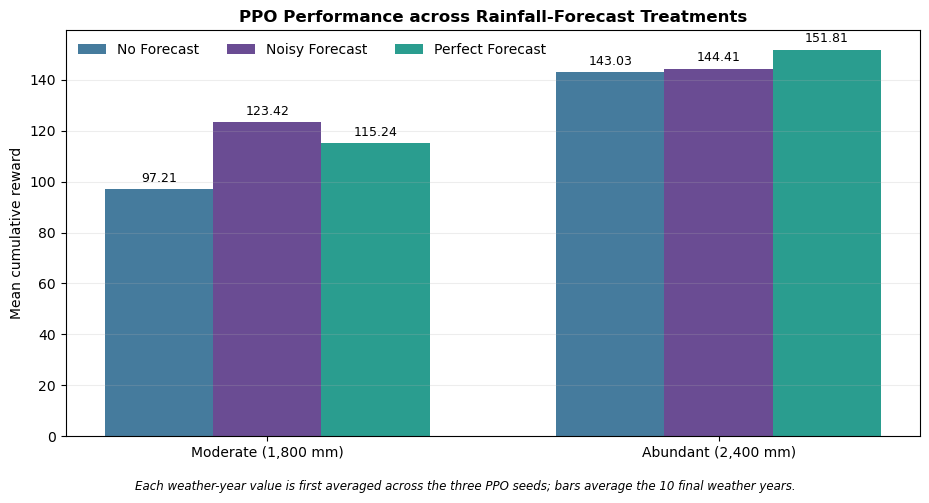

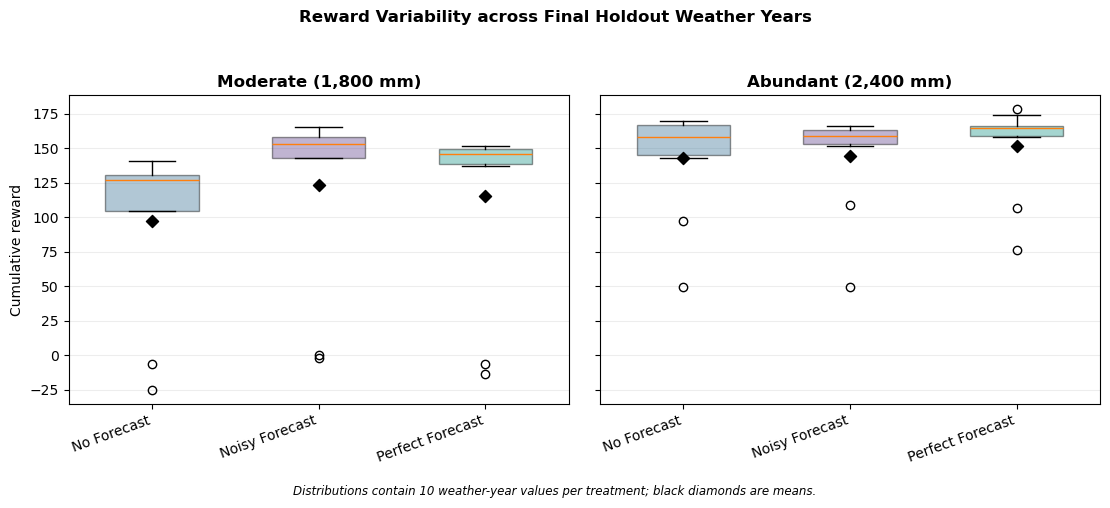

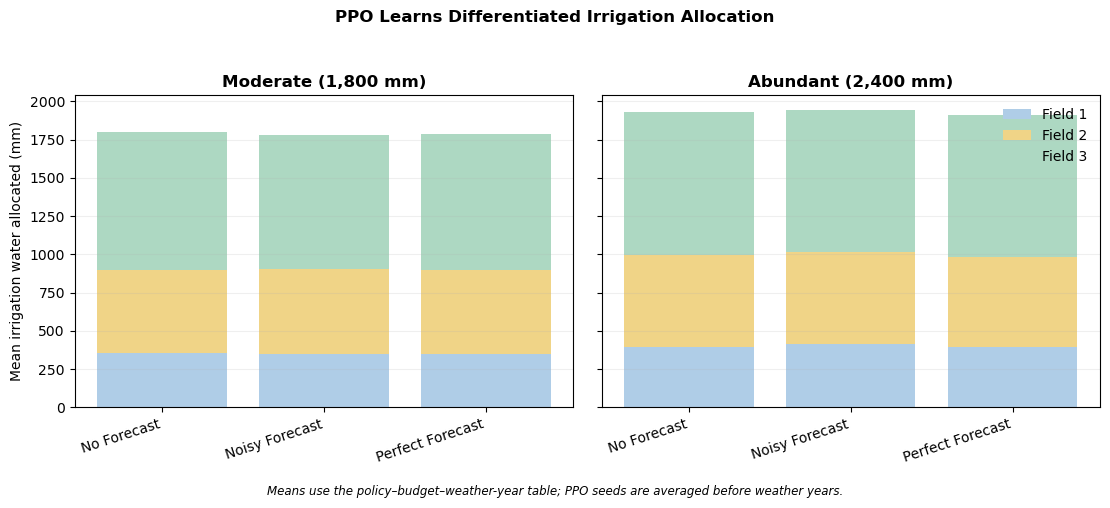

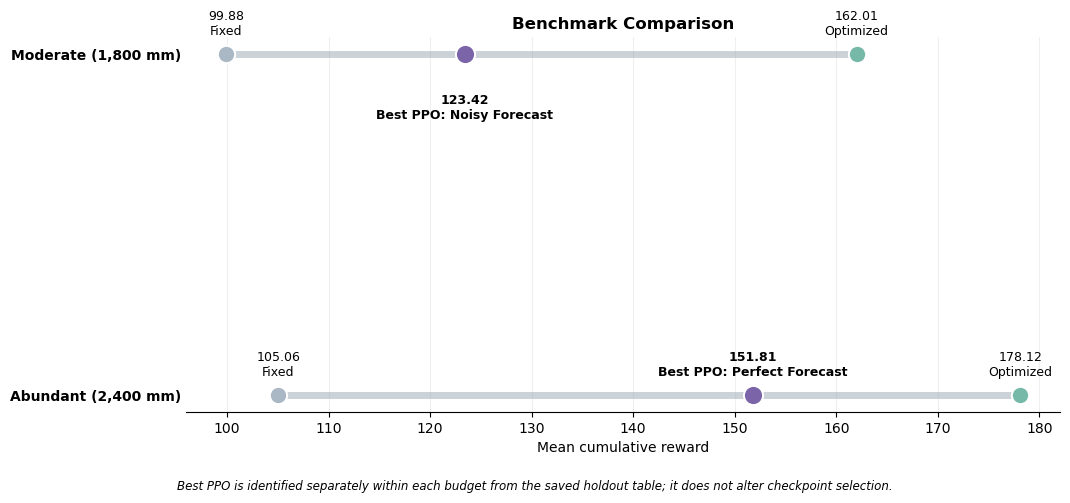

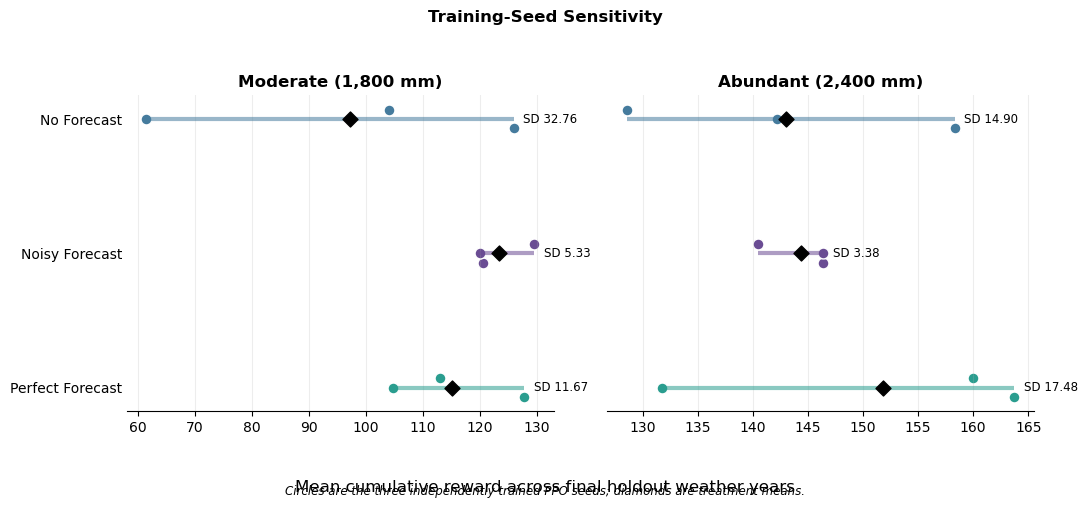

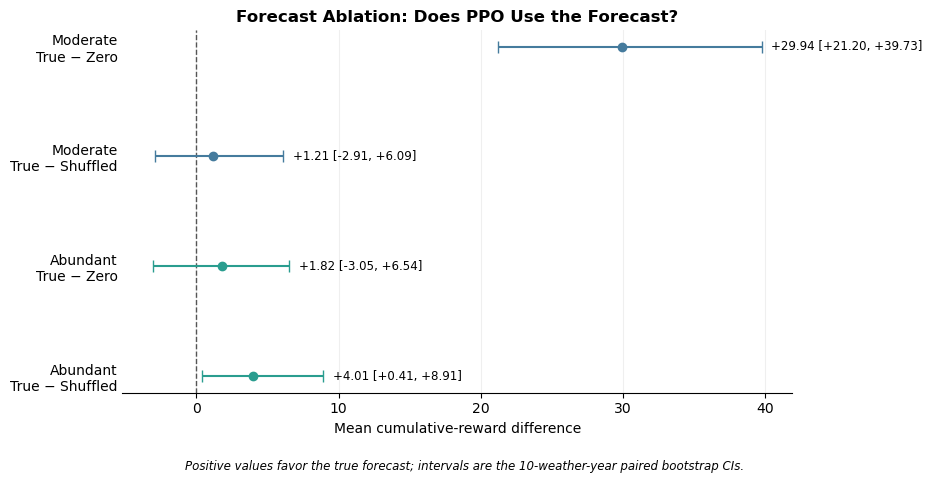

,policy_code,budget_name,mean,std
0,fixed_threshold,abundant,105.055598,86.967317
1,fixed_threshold,moderate,99.877530,93.314195
2,optimized_threshold,abundant,178.117793,29.980111
3,optimized_threshold,moderate,162.005445,50.793411
4,no_forecast,abundant,143.029911,39.226269
5,no_forecast,moderate,97.205470,60.803864
6,noisy_forecast,abundant,144.406637,37.382645
7,noisy_forecast,moderate,123.419193,65.983250
8,perfect_forecast,abundant,151.810559,32.984558
9,perfect_forecast,moderate,115.235946,66.150987


,comparison,budget_name,mean_paired_difference,bootstrap_ci_95_lower,bootstrap_ci_95_upper
0,perfect_forecast_minus_no_forecast,moderate,18.030477,9.911052,26.082147
11,noisy_forecast_minus_no_forecast,moderate,26.213723,19.409395,32.341077
22,perfect_forecast_minus_noisy_forecast,moderate,-8.183246,-11.430502,-4.629881
33,no_forecast_minus_fixed_threshold,moderate,-2.672060,-23.547505,26.584677
44,noisy_forecast_minus_fixed_threshold,moderate,23.541663,7.766152,47.236680
55,perfect_forecast_minus_fixed_threshold,moderate,15.358417,0.142328,37.632991
66,no_forecast_minus_optimized_threshold,moderate,-64.799975,-75.004988,-55.525553
77,noisy_forecast_minus_optimized_threshold,moderate,-38.586252,-49.408620,-28.982056
88,perfect_forecast_minus_optimized_threshold,moderate,-46.769499,-57.350198,-38.172299
99,perfect_forecast_minus_no_forecast,abundant,8.780648,4.399000,13.986573


,comparison,budget_name,mean_paired_difference,bootstrap_ci_95_lower,bootstrap_ci_95_upper
0,true_minus_zero,moderate,29.937421,21.202671,39.726657
11,true_minus_shuffled,moderate,1.208418,-2.907230,6.090487
22,true_minus_zero,abundant,1.824033,-3.051664,6.539661
33,true_minus_shuffled,abundant,4.012815,0.408710,8.911000


,figure,source_table,png,pdf
0,forecast-treatment cumulative reward,POLICY_WEATHER_YEAR_VALUES,outputs/final_analysis_v1/presentation_figures...,outputs/final_analysis_v1/presentation_figures...
1,reward variability across final weather years,POLICY_WEATHER_YEAR_VALUES,outputs/final_analysis_v1/presentation_figures...,outputs/final_analysis_v1/presentation_figures...
2,PPO field allocation,POLICY_WEATHER_YEAR_VALUES,outputs/final_analysis_v1/presentation_figures...,outputs/final_analysis_v1/presentation_figures...
3,benchmark comparison,POLICY_WEATHER_YEAR_VALUES,outputs/final_analysis_v1/presentation_figures...,outputs/final_analysis_v1/presentation_figures...
4,training-seed sensitivity,TRAINING_SEED_VARIABILITY,outputs/final_analysis_v1/presentation_figures...,outputs/final_analysis_v1/presentation_figures...
5,Perfect Forecast ablation,FORECAST_ABLATION_SUMMARY,outputs/final_analysis_v1/presentation_figures...,outputs/final_analysis_v1/presentation_figures...


Loaded 220 main episodes and 180 forecast-ablation episodes.


In [20]:
def load_saved_evaluation_results() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    required_paths = (
        HOLDOUT_MAIN_EPISODE_PATH,
        HOLDOUT_MAIN_DAILY_PATH,
        HOLDOUT_ABLATION_EPISODE_PATH,
        HOLDOUT_ABLATION_DAILY_PATH,
    )
    missing = [path for path in required_paths if not path.is_file()]
    if missing:
        raise FileNotFoundError(
            "Saved holdout results are required for analysis: "
            + ", ".join(str(path) for path in missing)
        )
    main_episodes = pd.read_csv(HOLDOUT_MAIN_EPISODE_PATH)
    main_daily = pd.read_csv(HOLDOUT_MAIN_DAILY_PATH)
    ablation_episodes = pd.read_csv(HOLDOUT_ABLATION_EPISODE_PATH)
    ablation_daily = pd.read_csv(HOLDOUT_ABLATION_DAILY_PATH)
    validate_evaluation_results(
        main_episodes,
        main_daily,
        expected_episodes=EXPECTED_MAIN_EPISODES,
    )
    validate_evaluation_results(
        ablation_episodes,
        ablation_daily,
        expected_episodes=EXPECTED_PERFECT_ABLATION_EPISODES,
    )
    return main_episodes, main_daily, ablation_episodes, ablation_daily


def run_results_analysis() -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    ANALYSIS_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    ANALYSIS_PRESENTATION_ROOT.mkdir(parents=True, exist_ok=True)
    main_episodes, main_daily, ablation_episodes, ablation_daily = (
        load_saved_evaluation_results()
    )
    tables = compute_analysis_tables(main_episodes, ablation_episodes)
    output_tables = {
        "policy_weather_year_values.csv": tables["POLICY_WEATHER_YEAR_VALUES"],
        "policy_summary.csv": tables["POLICY_SUMMARY"],
        "training_seed_variability.csv": tables["TRAINING_SEED_VARIABILITY"],
        "paired_policy_differences.csv": tables["PAIRED_POLICY_DIFFERENCES"],
        "paired_policy_summary.csv": tables["PAIRED_POLICY_SUMMARY"],
        "forecast_ablation_weather_year_values.csv": tables[
            "FORECAST_ABLATION_WEATHER_YEAR_VALUES"
        ],
        "forecast_ablation_summary.csv": tables["FORECAST_ABLATION_SUMMARY"],
        "budget_interaction_summary.csv": tables["BUDGET_INTERACTION_SUMMARY"],
    }
    for filename, table in output_tables.items():
        table.to_csv(ANALYSIS_OUTPUT_ROOT / filename, index=False)

    presentation_manifest = create_presentation_figures(tables)

    reward_summary = tables["POLICY_WEATHER_YEAR_VALUES"].groupby(
        ["policy_code", "budget_name"], observed=True, as_index=False
    )["cumulative_reward"].agg(["mean", "std"])
    paired_reward = tables["PAIRED_POLICY_SUMMARY"].loc[
        tables["PAIRED_POLICY_SUMMARY"]["metric"].eq("cumulative_reward")
    ]
    ablation_reward = tables["FORECAST_ABLATION_SUMMARY"].loc[
        tables["FORECAST_ABLATION_SUMMARY"]["aggregation_unit"].eq(
            "weather_year_after_seed_average"
        )
        & tables["FORECAST_ABLATION_SUMMARY"]["metric"].eq("cumulative_reward")
    ]
    display(reward_summary)
    display(
        paired_reward[
            [
                "comparison",
                "budget_name",
                "mean_paired_difference",
                "bootstrap_ci_95_lower",
                "bootstrap_ci_95_upper",
            ]
        ]
    )
    display(
        ablation_reward[
            [
                "comparison",
                "budget_name",
                "mean_paired_difference",
                "bootstrap_ci_95_lower",
                "bootstrap_ci_95_upper",
            ]
        ]
    )
    display(presentation_manifest)
    print(
        f"Loaded {len(main_episodes)} main episodes and {len(ablation_episodes)} "
        "forecast-ablation episodes."
    )
    return tables, presentation_manifest


analysis_tables, presentation_figure_manifest = run_results_analysis()
